In [ ]:
import pandas as pd

# Step 1: Load the raw dataset
file_path = '/content/bank-full.csv'  # Replace with your file name
raw_data = pd.read_csv(file_path, header=None, sep=';')  # Directly use ';' as delimiter to avoid extra splitting later

# Step 2: Treat the first row as column headers
raw_data.columns = raw_data.iloc[0]  # Assign the first row as headers
raw_data = raw_data[1:]  # Remove the first row from the data
# Step 3: Remove double quotes from all cells
raw_data = raw_data.replace('"', '', regex=True)
# Step 4: Save the cleaned data to a new CSV file
output_file_path = 'formatted_bank_data.csv'
raw_data.to_csv(output_file_path, index=False)
print(f"Formatted data saved to {output_file_path}")


<ipython-input-3-503eaeffc8f4>:5: DtypeWarning: Columns (0,5,9,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(file_path, header=None, sep=';')  # Directly use ';' as delimiter to avoid extra splitting later


Formatted data saved to formatted_bank_data.csv


In [ ]:
import pandas as pd

# Step 1: Load the cleaned data
file_path = 'formatted_bank_data.csv'

try:
    cleaned_data = pd.read_csv(file_path)
    print(f"Data successfully loaded from {file_path}.")
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
    exit()
except pd.errors.EmptyDataError:
    print(f"Error: The file {file_path} is empty.")
    exit()

# Step 2: Preview the first few rows and basic information
print("Preview of the first few rows:")
print(cleaned_data.head())

print("\nDataset Info:")
print(cleaned_data.info())


Data successfully loaded from formatted_bank_data.csv.
Preview of the first few rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Dataset Info:
<class 'pa

In [ ]:
# Check for missing values
print("\nChecking for missing values:")
missing_values = cleaned_data.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "No missing values found.")

# Check data types of columns
print("\nColumn Data Types:")
print(cleaned_data.dtypes)

# Show unique values in each column (limit to first 5 unique values for large datasets)
print("\nUnique Values in Each Column:")
for col in cleaned_data.columns:
    print(f"{col}: {cleaned_data[col].unique()[:5]}...")  # Display first 5 unique values



Checking for missing values:
No missing values found.

Column Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Unique Values in Each Column:
age: [58 44 33 47 35]...
job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown']...
marital: ['married' 'single' 'divorced']...
education: ['tertiary' 'secondary' 'unknown' 'primary']...
default: ['no' 'yes']...
balance: [2143   29    2 1506    1]...
housing: ['yes' 'no']...
loan: ['no' 'yes']...
contact: ['unknown' 'cellular' 'telephone']...
day: [5 6 7 8 9]...
month: ['may' 'jun' 'jul' 'aug' 'oct']...
duration: [261 151  76  92 198]...
campaign: [1 2 3 5 4]...
pdays: [ -1 151 166  91  86]...
previous: [0 3 1 4 2]...


In [ ]:
# Generate descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
print(cleaned_data.describe())

# Generate descriptive statistics for categorical columns
print("\nDescriptive Statistics for Categorical Columns:")
categorical_columns = cleaned_data.select_dtypes(include=['object']).columns
print(cleaned_data[categorical_columns].describe())



Descriptive Statistics for Numerical Columns:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000

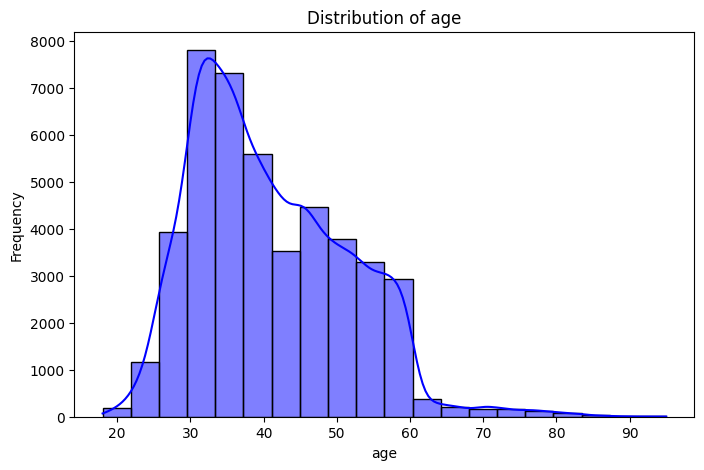

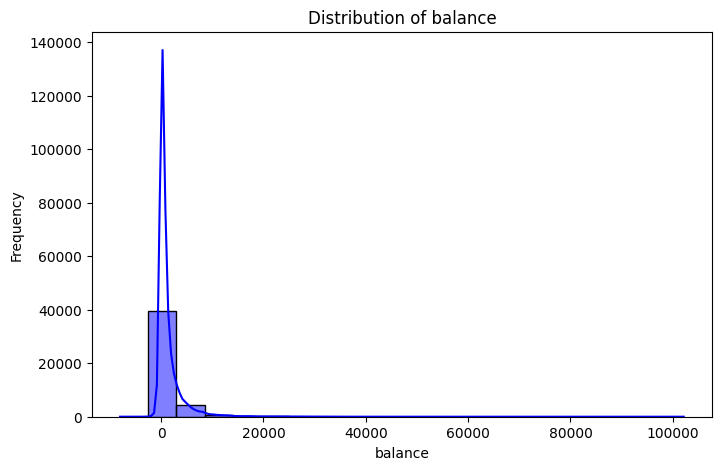

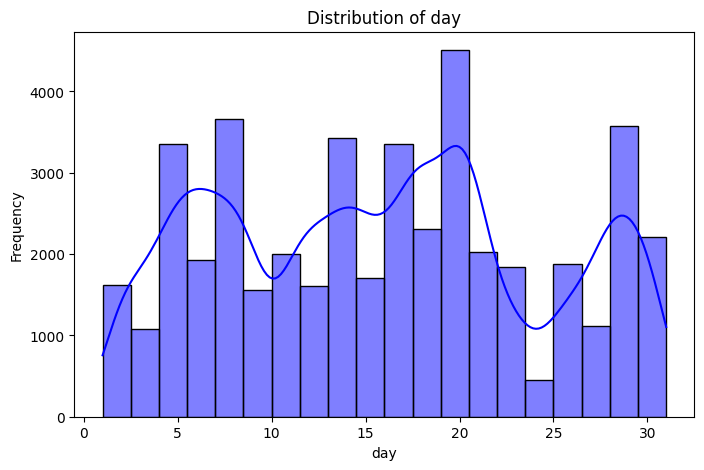

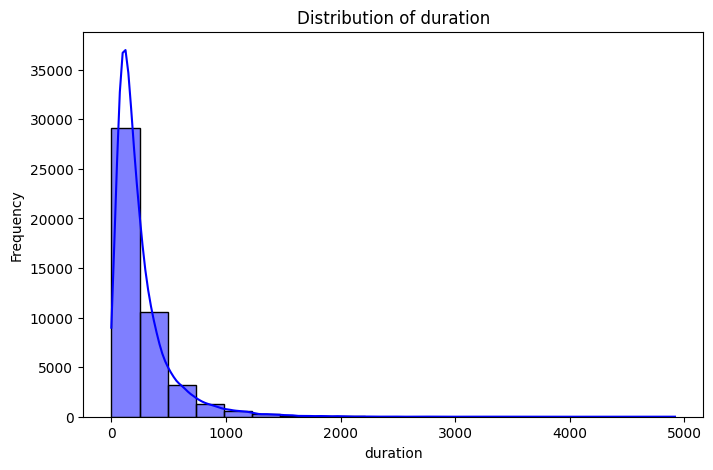

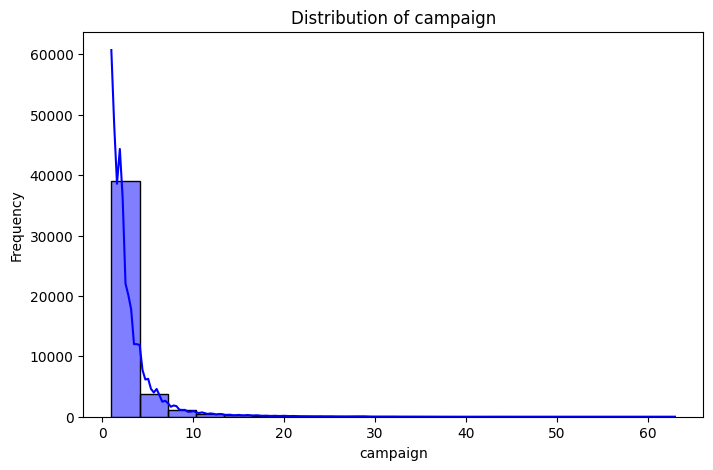

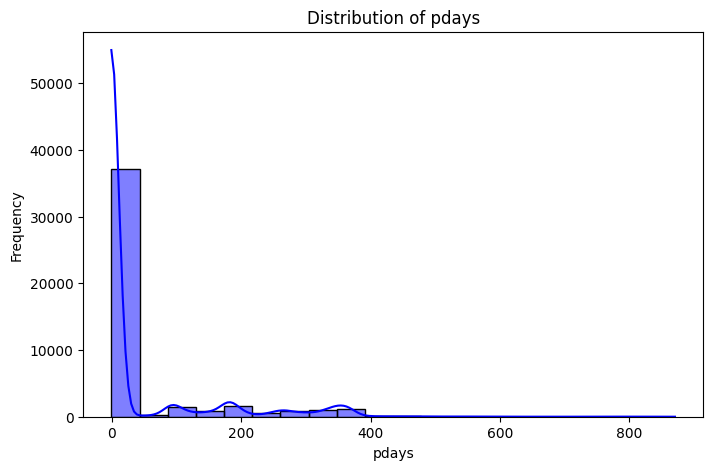

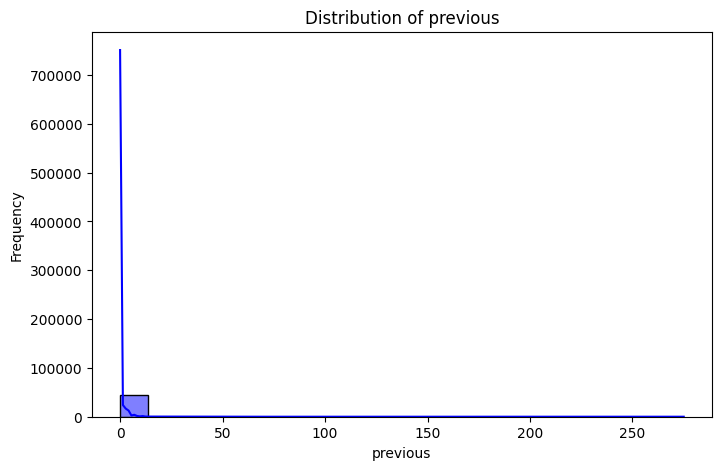

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


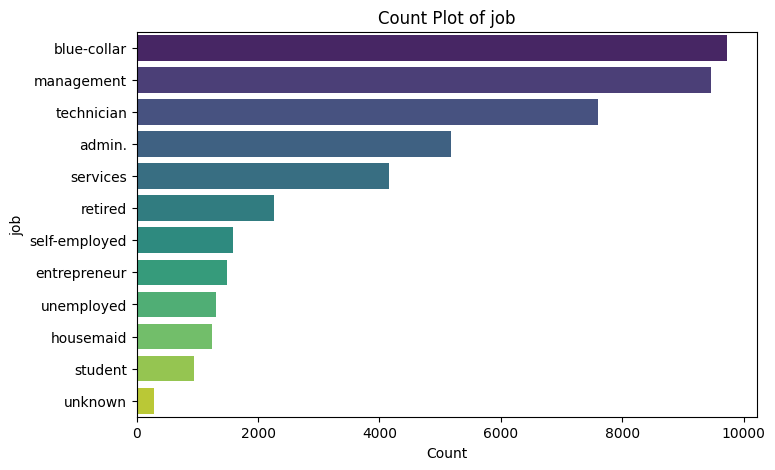

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


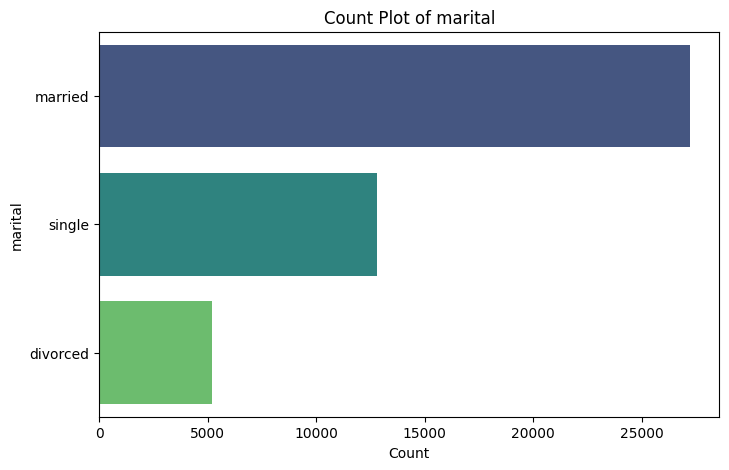

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


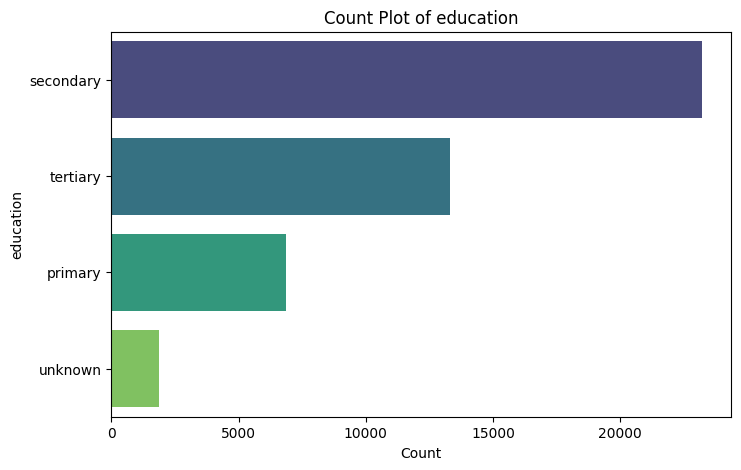

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


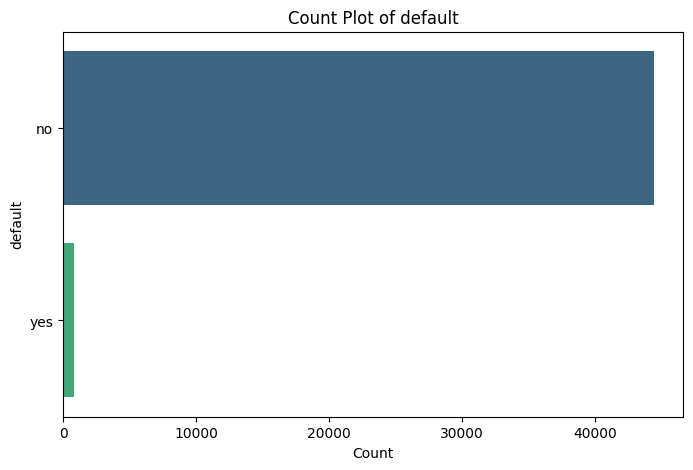

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


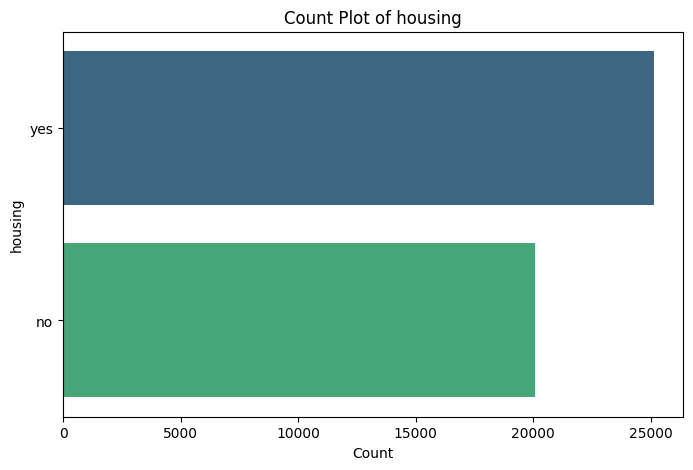

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


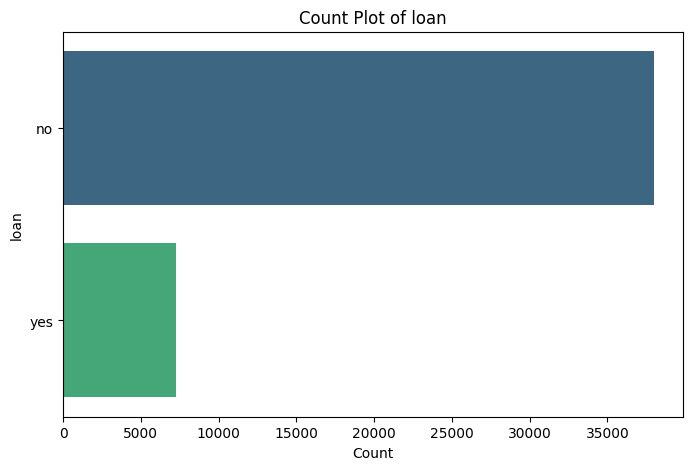

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


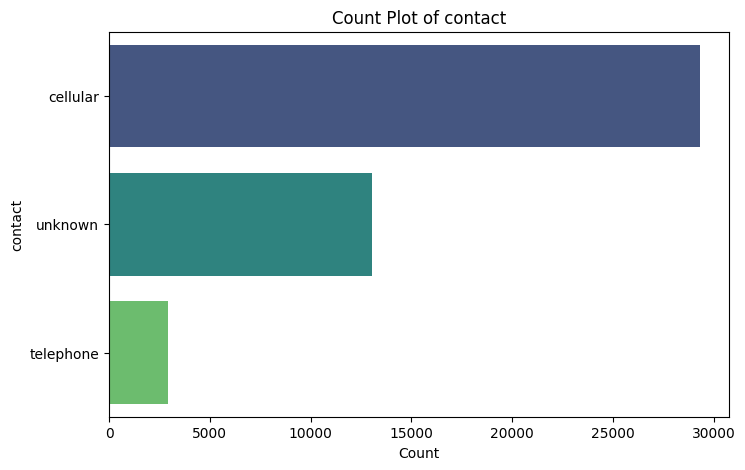

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


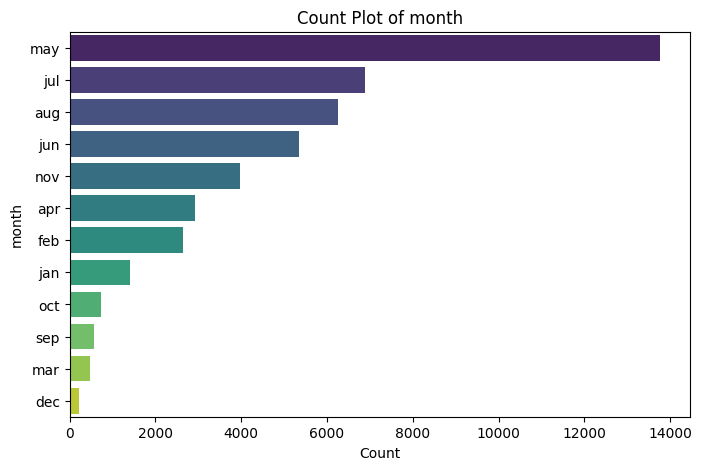

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


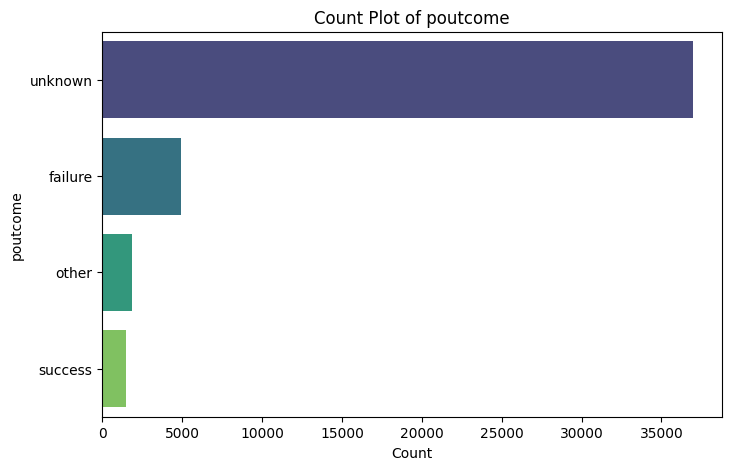

<ipython-input-7-311b6950fc33>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')


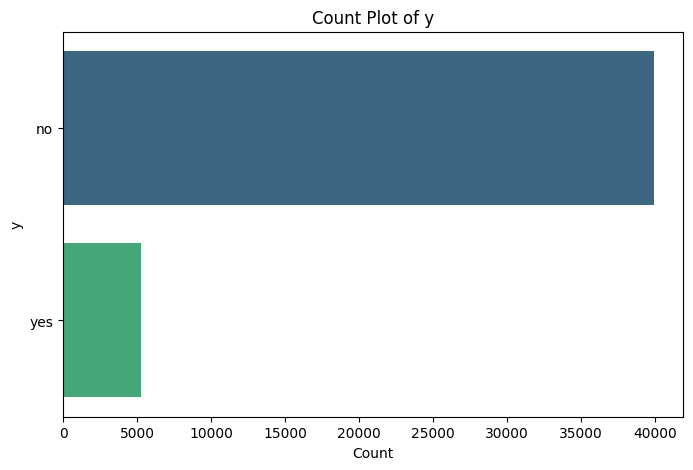

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distribution of numerical columns
numerical_columns = cleaned_data.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(cleaned_data[col].astype(float), kde=True, bins=20, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Visualize count plots for categorical columns
for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index, palette='viridis')
    plt.title(f"Count Plot of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

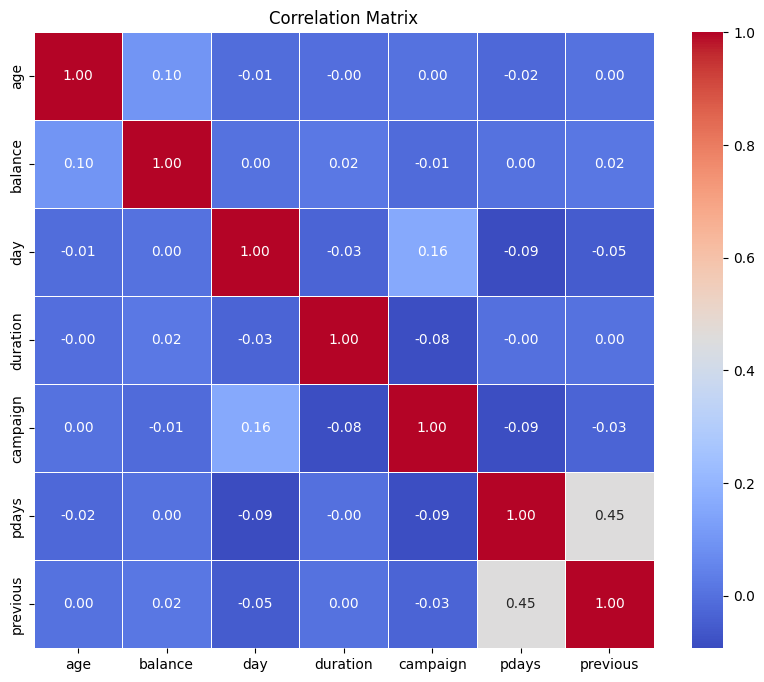

In [ ]:
# Calculate and visualize the correlation matrix
correlation_matrix = cleaned_data.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Save the cleaned dataset for further processing
output_file_path = 'final_cleaned_bank_data.csv'
cleaned_data.to_csv(output_file_path, index=False)
print(f"\nCleaned data saved to {output_file_path}.")



Cleaned data saved to final_cleaned_bank_data.csv.


In [ ]:
print(cleaned_data.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Load the cleaned dataset
file_path = 'formatted_bank_data.csv'
cleaned_data = pd.read_csv(file_path)

# Step 2: Strip column names to ensure no quotes or spaces
cleaned_data.columns = cleaned_data.columns.str.strip().str.replace('"', '')

# Step 3: Check column names to identify the target
print("Columns in the dataset:", cleaned_data.columns)

# Step 4: Separate Features (X) and Target (y)
X = cleaned_data.drop('y', axis=1)  # Drop the target column
y = cleaned_data['y'].map({'yes': 1, 'no': 0})  # Encode target variable: 'yes' -> 1, 'no' -> 0

print("Data loaded and target encoded successfully!")


Columns in the dataset: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
Data loaded and target encoded successfully!


In [ ]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),  # Encode categorical
    ])

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data split into training and testing sets.")


Data split into training and testing sets.


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.74      0.19      0.30      1058

    accuracy                           0.90      9043
   macro avg       0.82      0.59      0.62      9043
weighted avg       0.88      0.90      0.87      9043

ROC-AUC Score: 0.9222373471999129


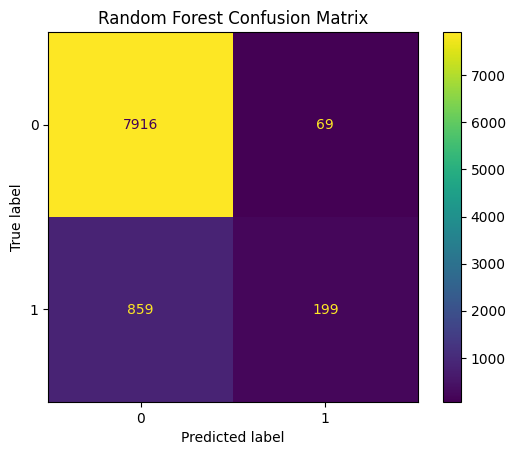

In [ ]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10))
])

# Train the Random Forest model
rf_pipeline.fit(X_train, y_train)

# Predict and evaluate Random Forest
rf_predictions = rf_pipeline.predict(X_test)
rf_probabilities = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_probabilities))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_predictions)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.48      0.56      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.73      0.75      9043
weighted avg       0.90      0.91      0.90      9043

ROC-AUC Score: 0.9326785927773364


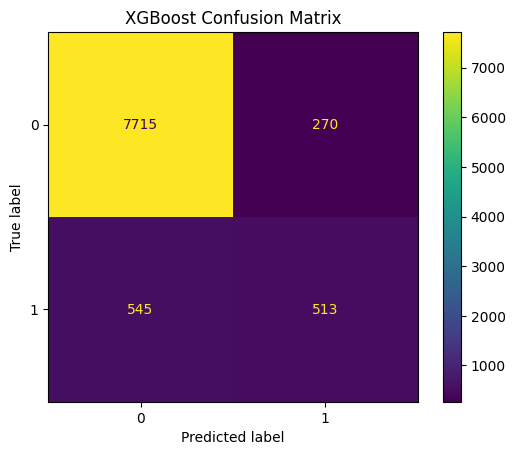

In [ ]:
# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42))
])

# Train the XGBoost model
xgb_pipeline.fit(X_train, y_train)

# Predict and evaluate XGBoost
xgb_predictions = xgb_pipeline.predict(X_test)
xgb_probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_predictions))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_probabilities))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_predictions)
ConfusionMatrixDisplay(cm).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()


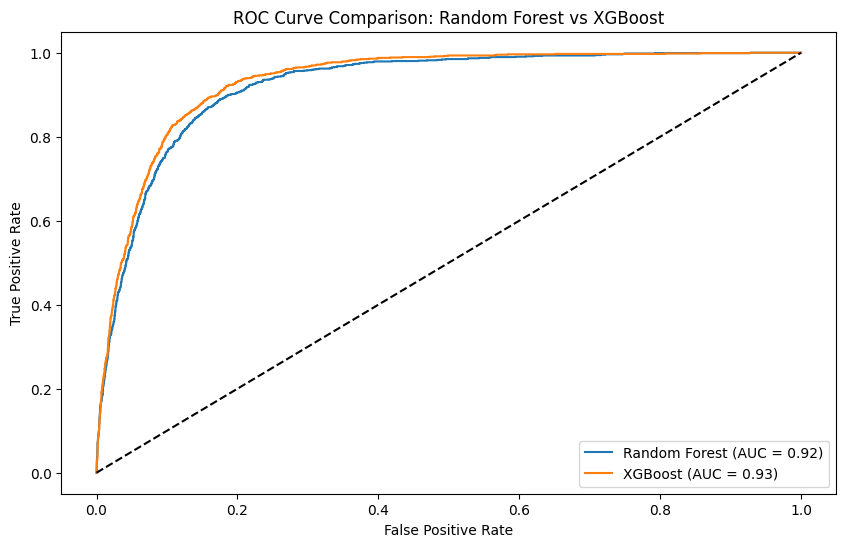

In [ ]:
# ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)

plt.figure(figsize=(10, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probabilities):.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_probabilities):.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Random Forest vs XGBoost")
plt.legend()
plt.show()


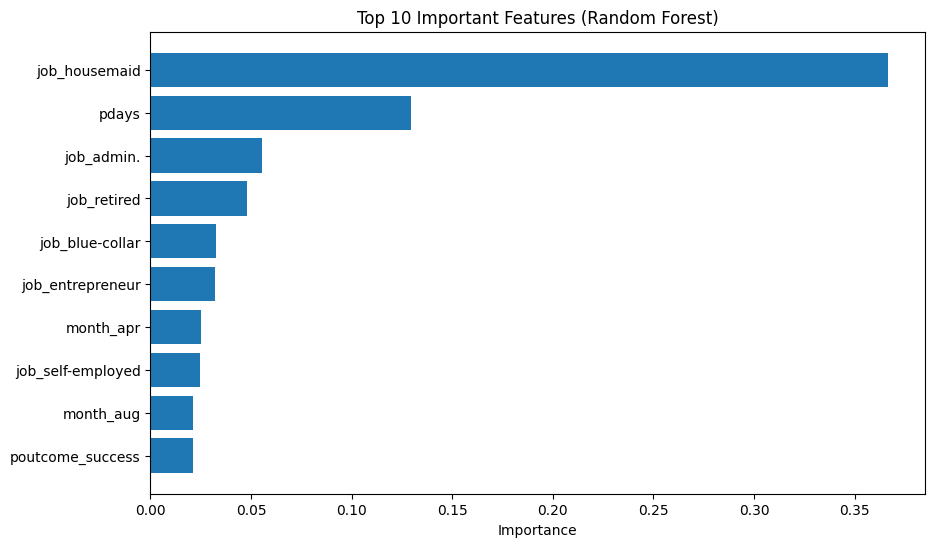

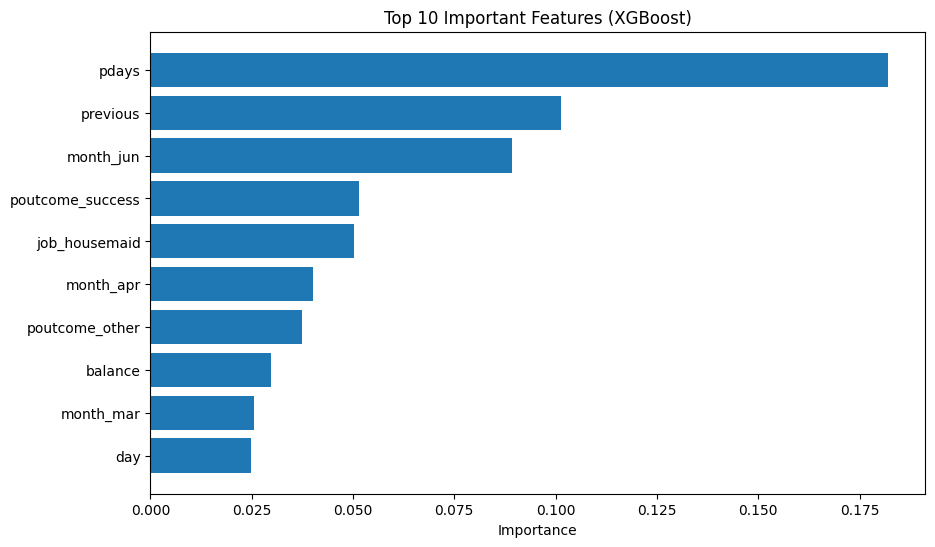

In [ ]:
# Feature Importance: Random Forest
rf_model = rf_pipeline.named_steps['classifier']
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
feature_names.extend(numerical_features)

importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'][:10], rf_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

# Feature Importance: XGBoost
xgb_model = xgb_pipeline.named_steps['classifier']
xgb_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_model.feature_importances_})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance_df['Feature'][:10], xgb_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Importance")
plt.show()


In [ ]:
print(cleaned_data['y'].value_counts(normalize=True))


y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [ ]:
!pip install imbalanced-learn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter


# Assuming X and y are already defined...

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),  # Encode categorical
    ])

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data split into training and testing sets.")


# Apply preprocessing before SMOTE
X_train = preprocessor.fit_transform(X_train)

counter = Counter(y_train)
print('Before', counter)

# oversampling the train dataset using SMOTE
smt = SMOTE()
X_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)

counter = Counter(y_train_sm)
print('After', counter)

Data split into training and testing sets.
Before Counter({0: 31937, 1: 4231})
After Counter({0: 31937, 1: 31937})


Before Balancing: Counter({0: 31937, 1: 4231})


<ipython-input-15-a97180896600>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')


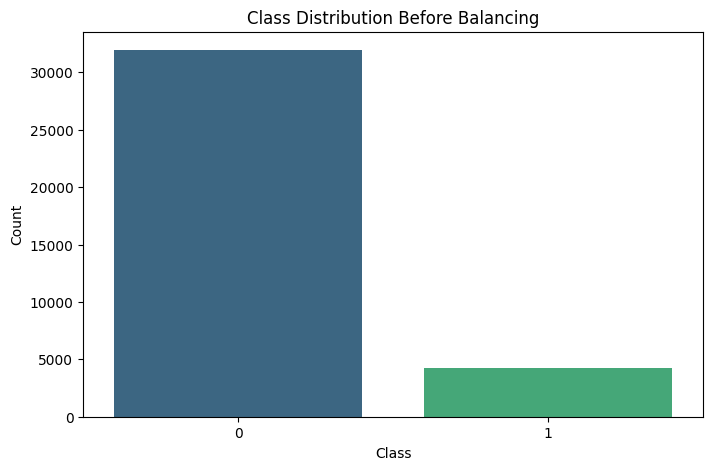

ValueError: could not convert string to float: 'technician'

In [ ]:
from imblearn.over_sampling import ADASYN
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution before ADASYN
counter = Counter(y_train)
print('Before Balancing:', counter)

# Visualize class distribution before balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply ADASYN on the training set
adasyn = ADASYN(random_state=42, n_neighbors=5)  # n_neighbors controls the synthetic sampling
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

# Check class distribution after ADASYN
counter_ada = Counter(y_train_ada)
print('After Balancing:', counter_ada)

# Visualize class distribution after balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter_ada.keys()), y=list(counter_ada.values()), palette='viridis')
plt.title("Class Distribution After Balancing (ADASYN)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Optional: Shape verification
print("Original X_train shape:", X_train.shape)
print("Balanced X_train shape (ADASYN):", X_train_ada.shape)


Before Balancing: Counter({0: 31937, 1: 4231})


<ipython-input-22-5bf595e74080>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')


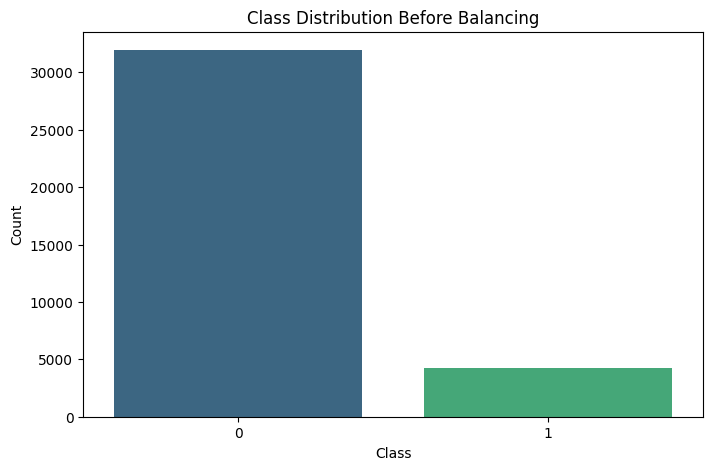

ValueError: could not convert string to float: 'technician'

In [ ]:
from imblearn.combine import SMOTETomek
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution before SMOTE + Tomek
counter = Counter(y_train)
print('Before Balancing:', counter)

# Visualize class distribution before balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply SMOTE + Tomek on the training set
smtom = SMOTETomek(random_state=139)
X_train_smtom, y_train_smtom = smtom.fit_resample(X_train, y_train)

# Check class distribution after SMOTE + Tomek
counter_smtom = Counter(y_train_smtom)
print('After Balancing:', counter_smtom)

# Visualize class distribution after balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter_smtom.keys()), y=list(counter_smtom.values()), palette='viridis')
plt.title("Class Distribution After Balancing (SMOTE + Tomek)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Shape verification
print("Original X_train shape:", X_train.shape)
print("Balanced X_train shape (SMOTE + Tomek):", X_train_smtom.shape)


Before Balancing: Counter({'no': 31937, 'yes': 4231})


<ipython-input-31-54018657e42c>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')


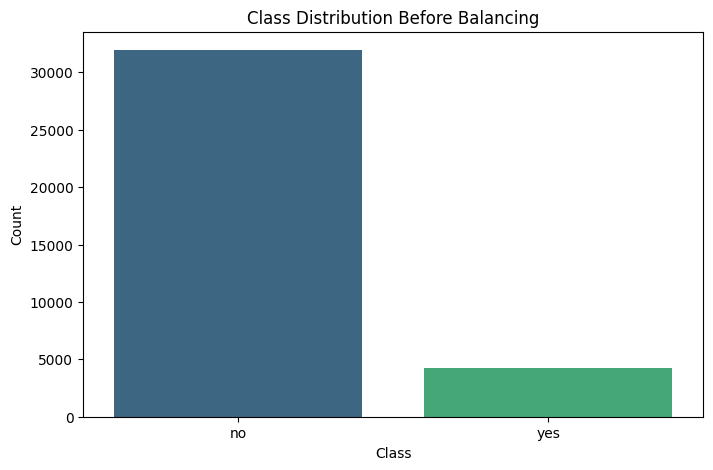

After Balancing: Counter({'no': 31127, 'yes': 31127})


<ipython-input-31-54018657e42c>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter_smtom.keys()), y=list(counter_smtom.values()), palette='viridis')


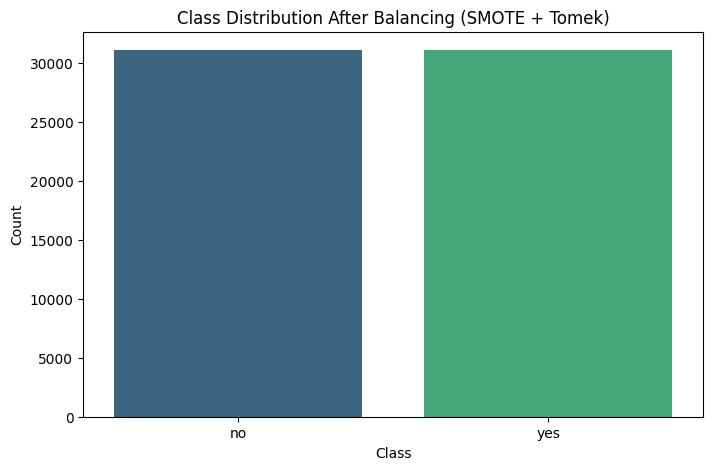

Original X_train shape: (36168, 42)
Balanced X_train shape (SMOTE + Tomek): (62254, 42)


In [ ]:
from imblearn.combine import SMOTETomek
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of instances in each class before SMOTE + Tomek
counter = Counter(y_train)
print('Before Balancing:', counter)

# Visualize class distribution before balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette='viridis')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply SMOTE + Tomek on the training dataset
smtom = SMOTETomek(random_state=139)
X_train_smtom, y_train_smtom = smtom.fit_resample(X_train, y_train)

# Count the number of instances in each class after SMOTE + Tomek
counter_smtom = Counter(y_train_smtom)
print('After Balancing:', counter_smtom)

# Visualize class distribution after balancing
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counter_smtom.keys()), y=list(counter_smtom.values()), palette='viridis')
plt.title("Class Distribution After Balancing (SMOTE + Tomek)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Verify shapes of X_train before and after balancing
print("Original X_train shape:", X_train.shape)
print("Balanced X_train shape (SMOTE + Tomek):", X_train_smtom.shape)


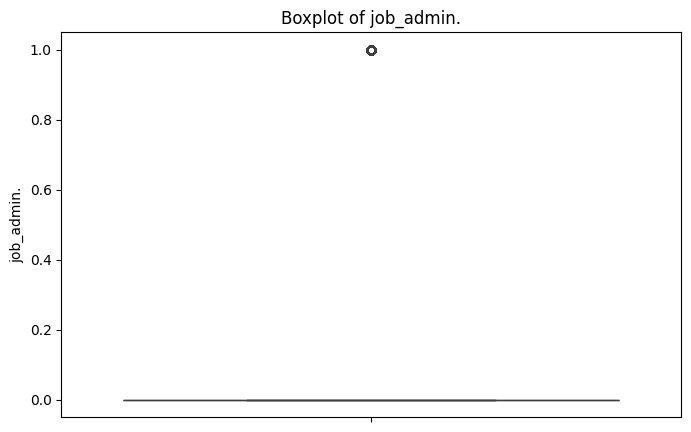

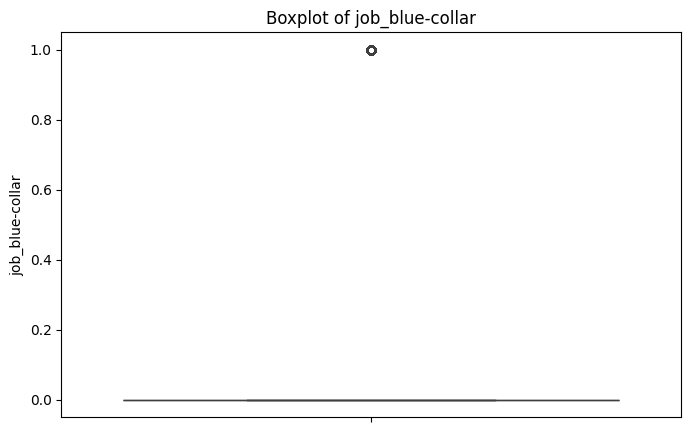

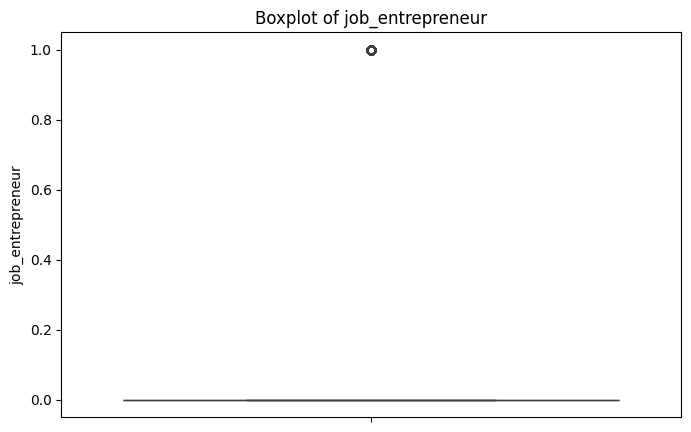

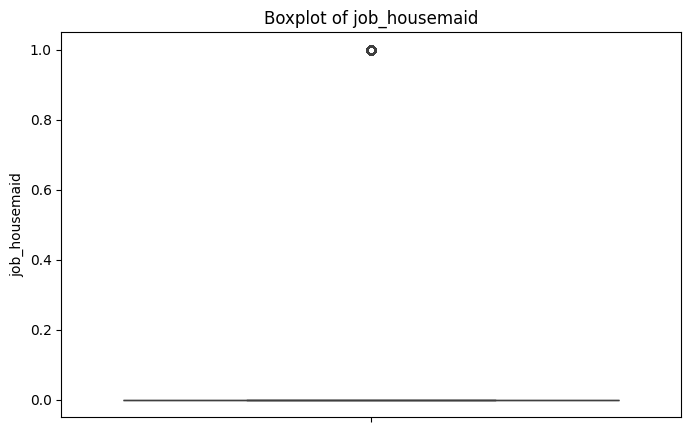

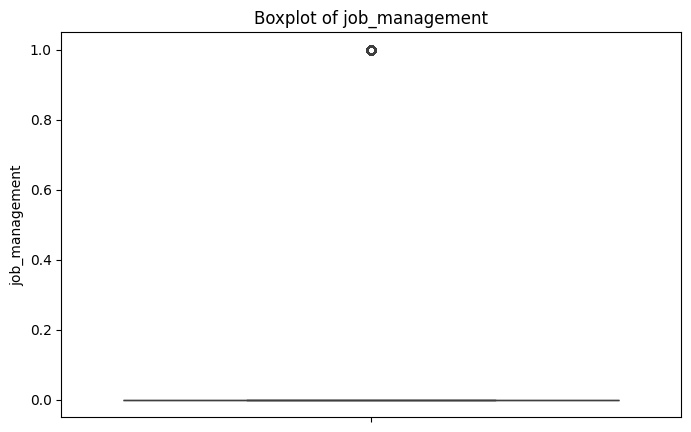

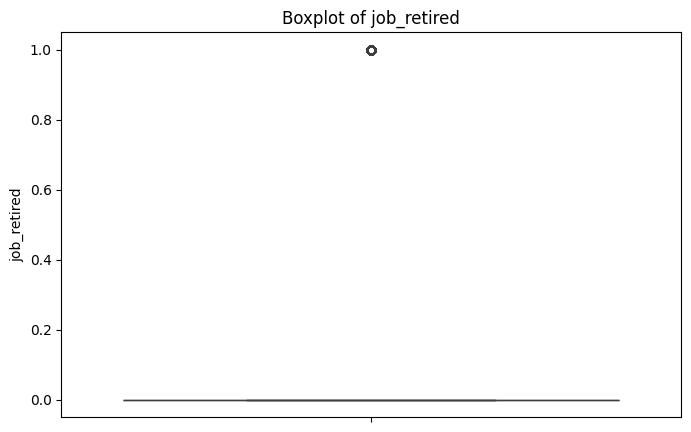

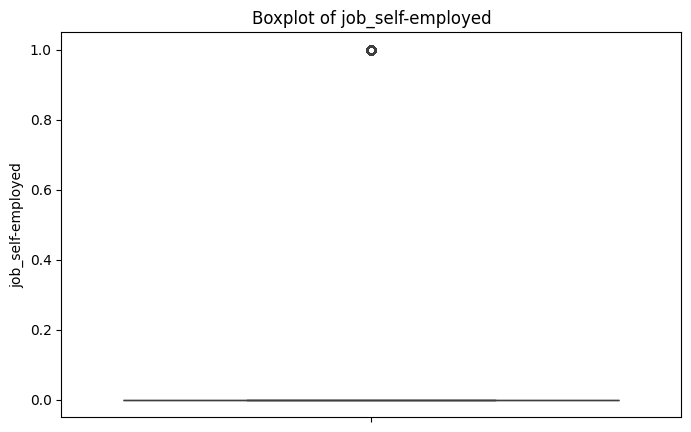

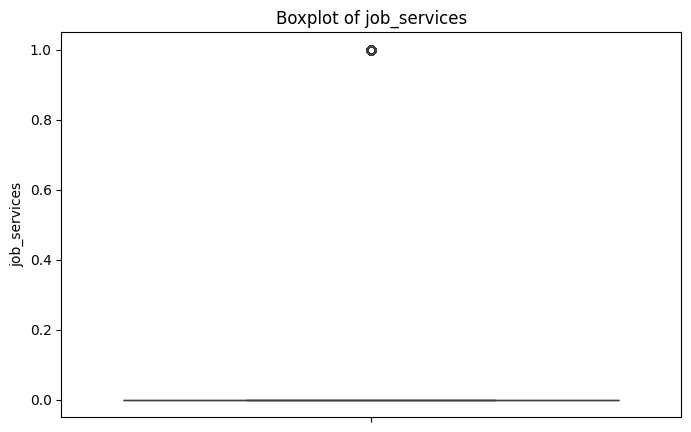

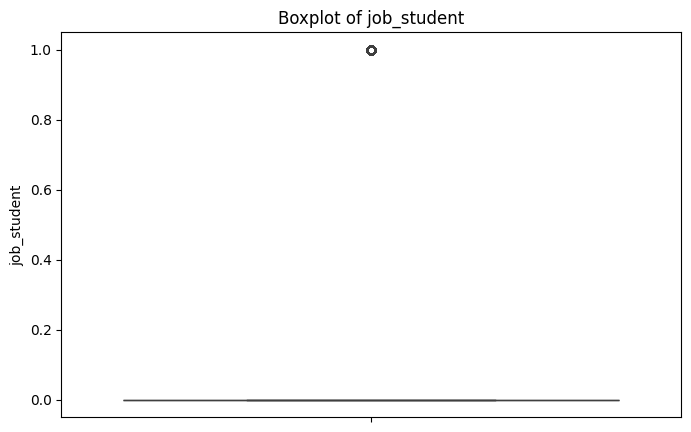

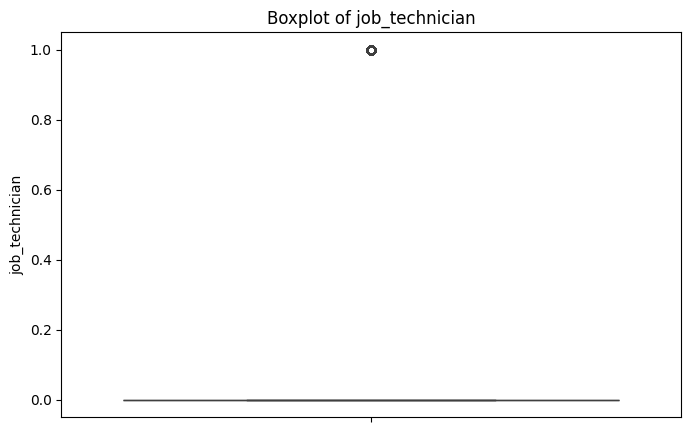

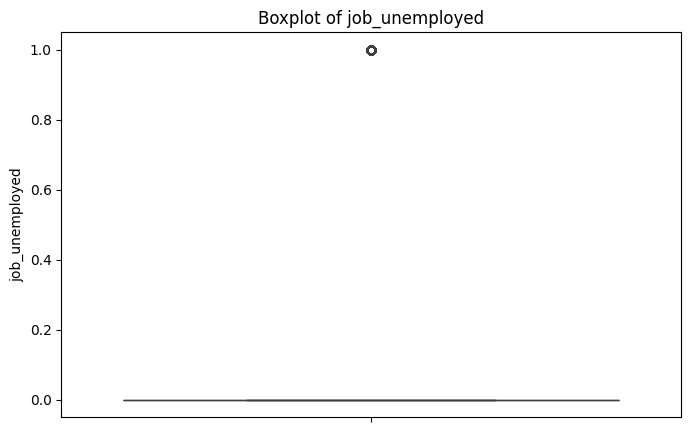

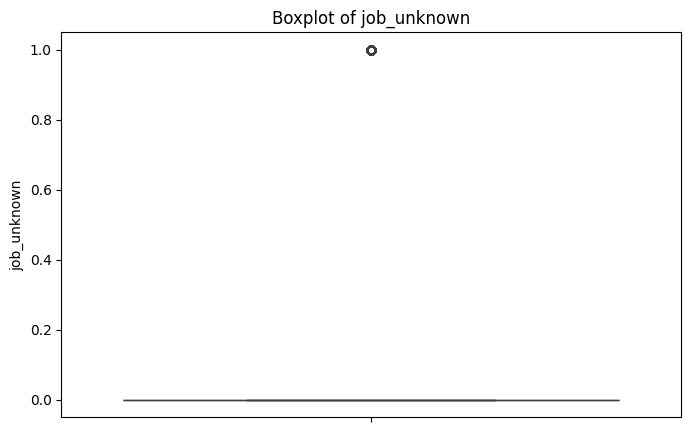

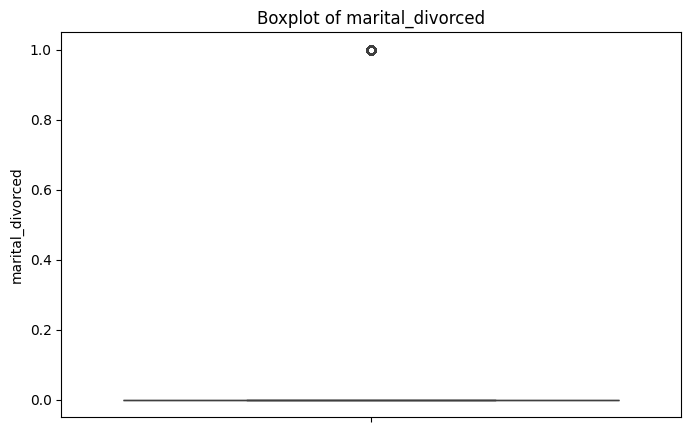

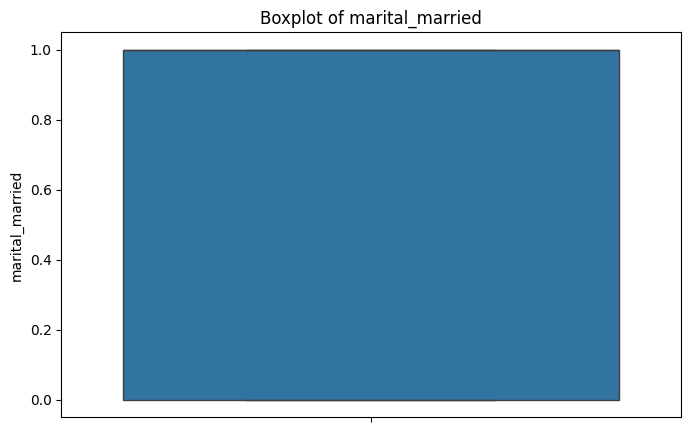

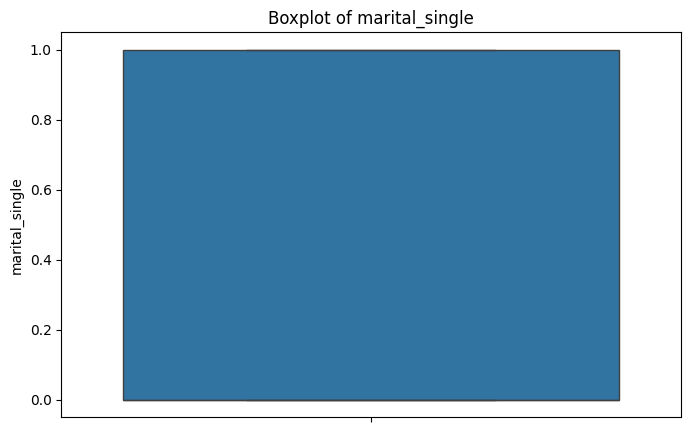

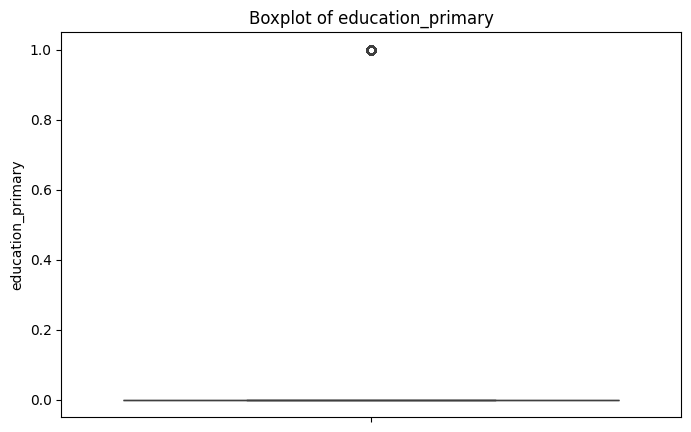

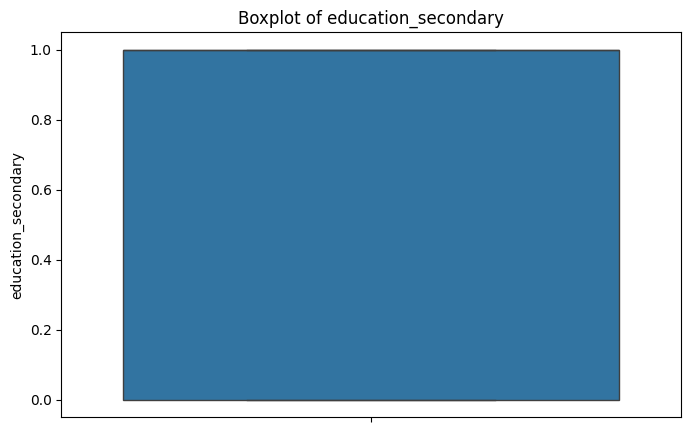

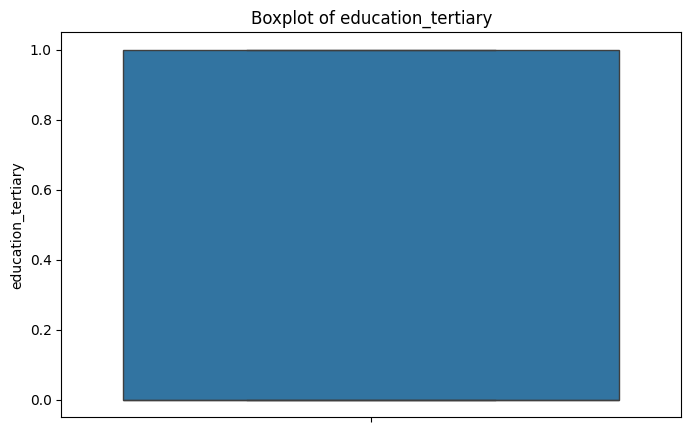

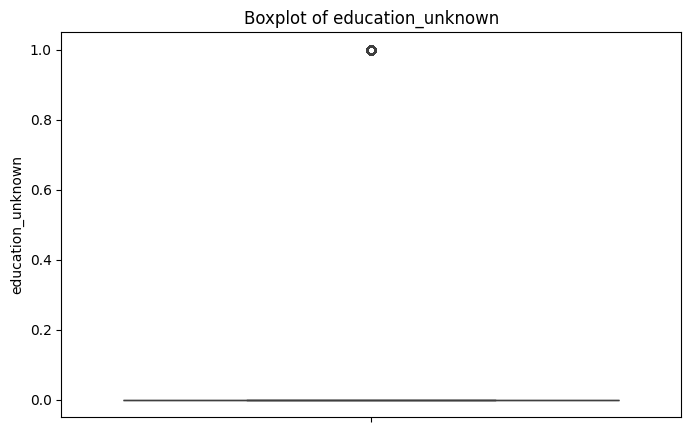

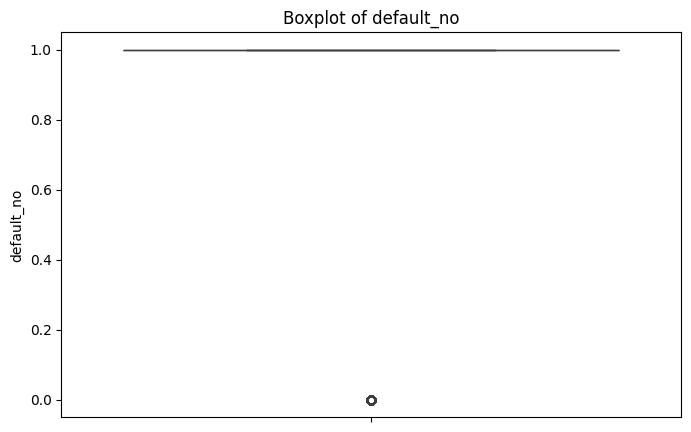

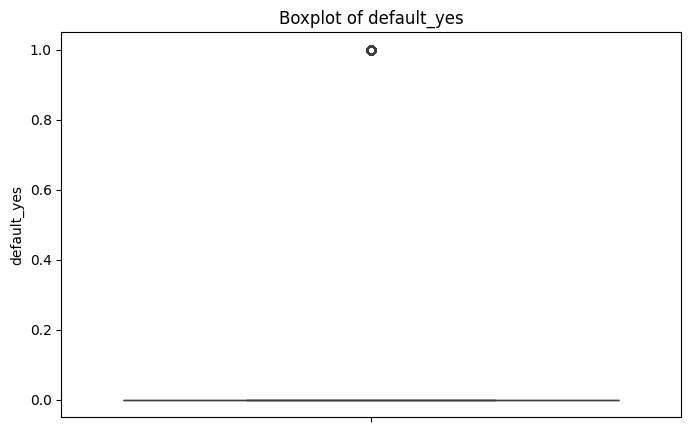

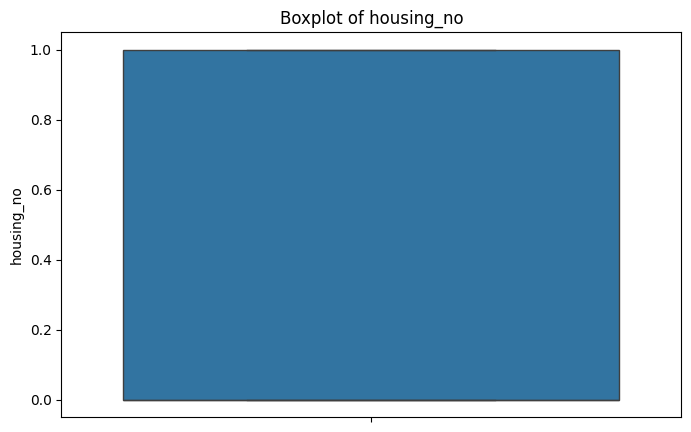

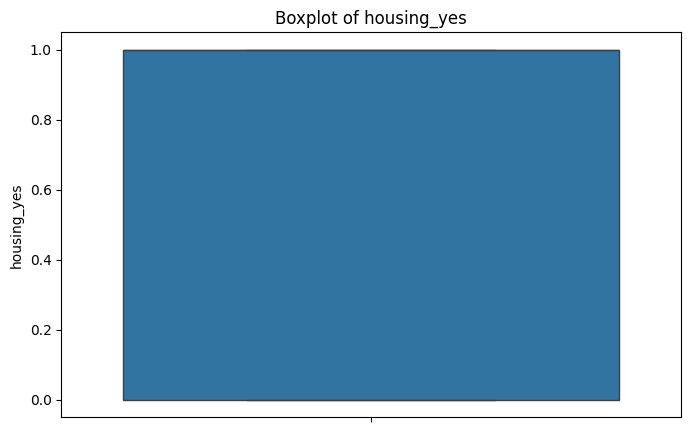

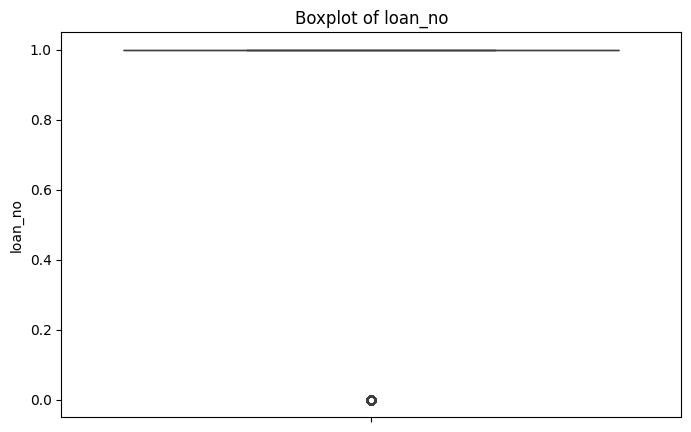

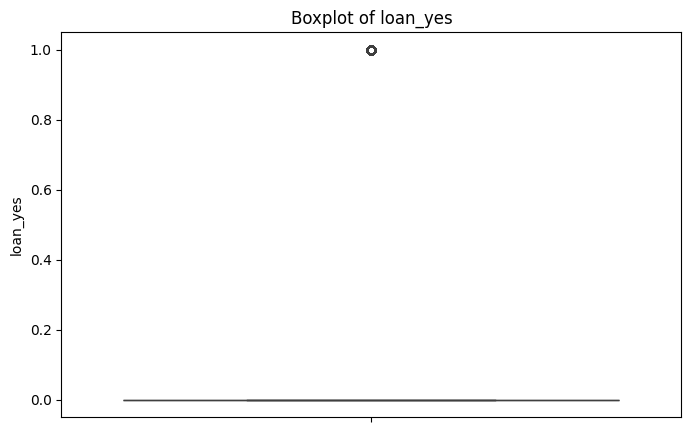

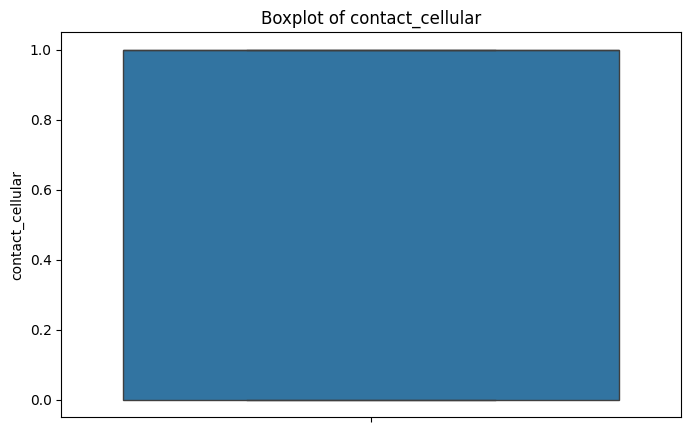

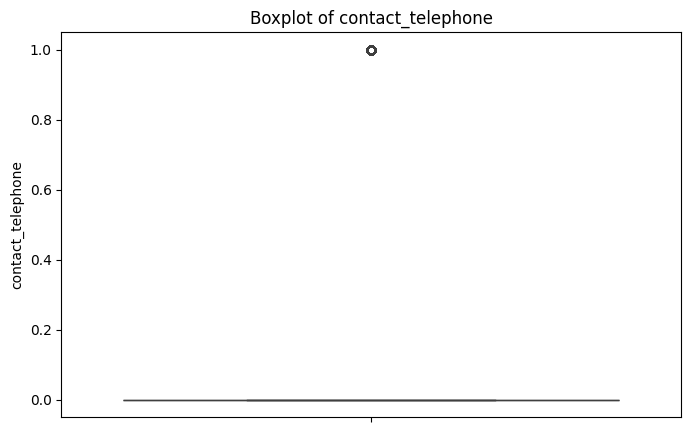

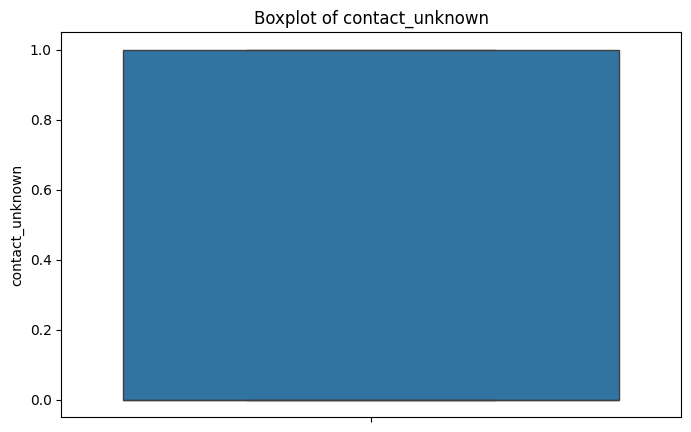

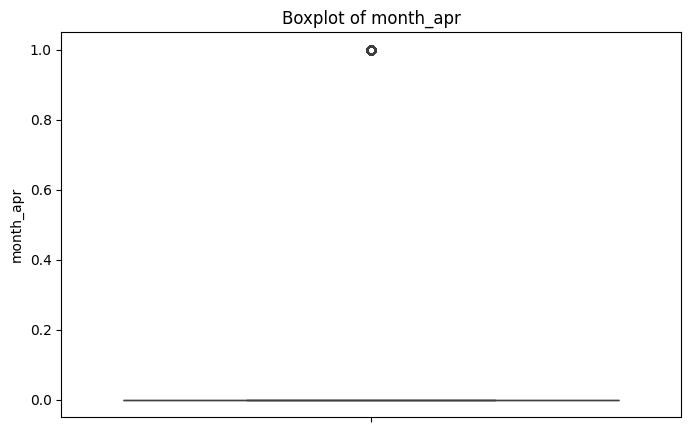

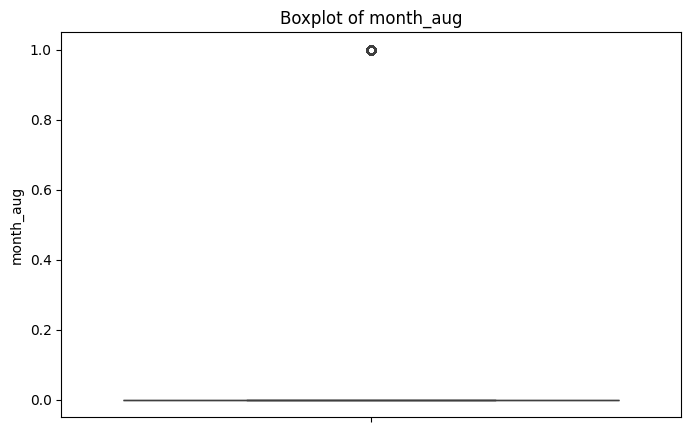

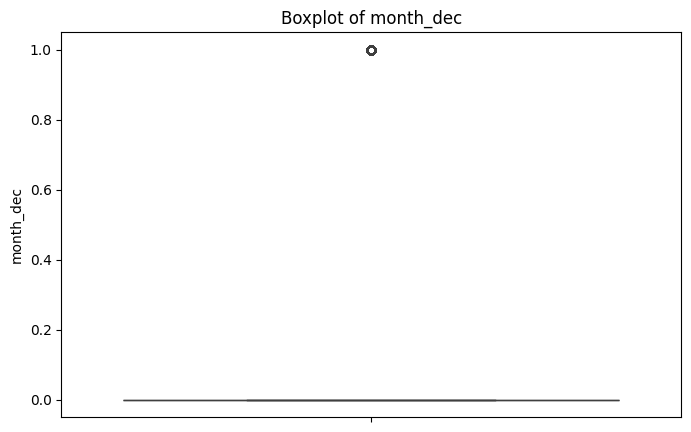

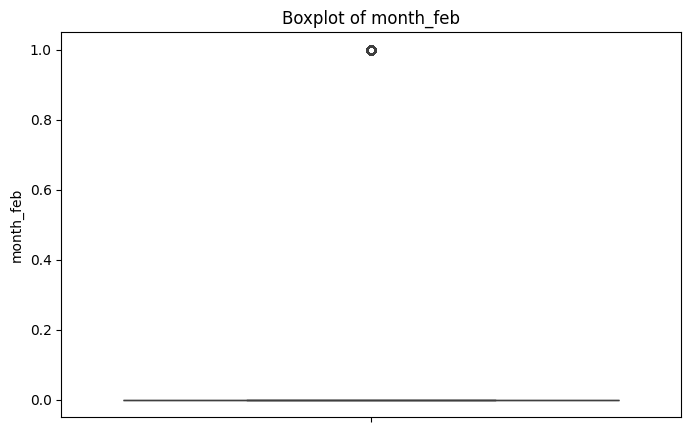

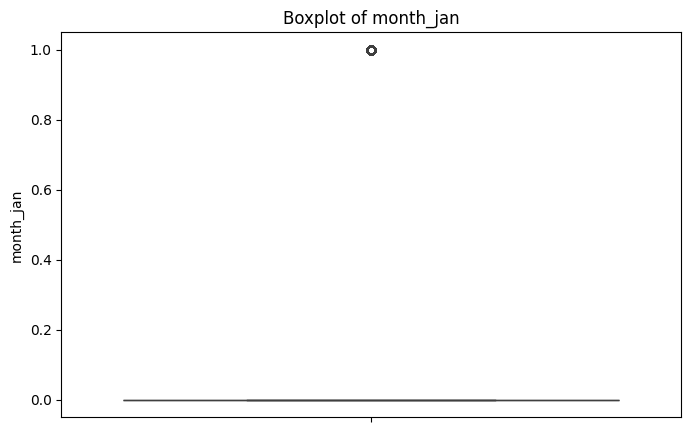

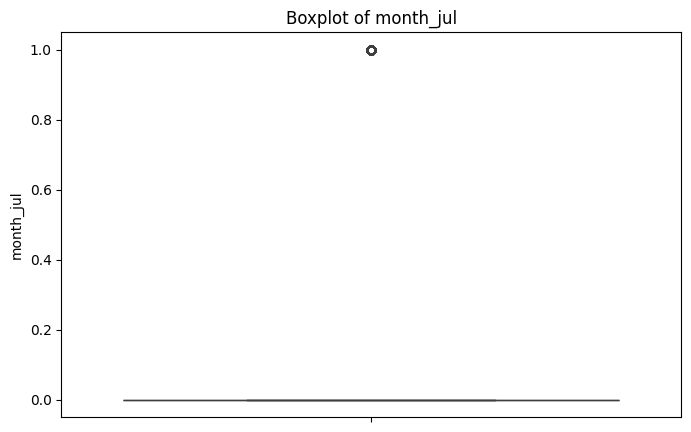

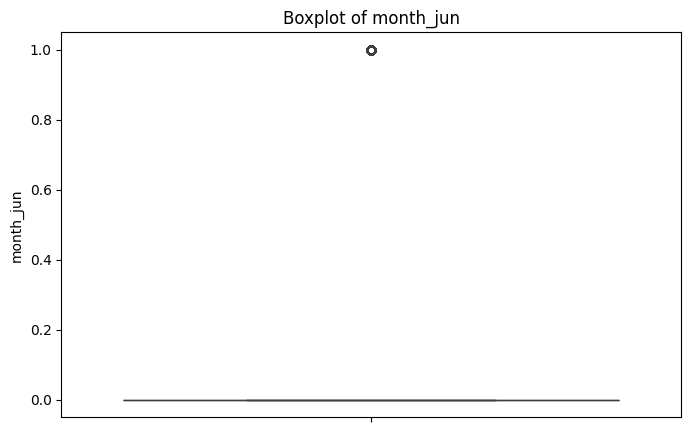

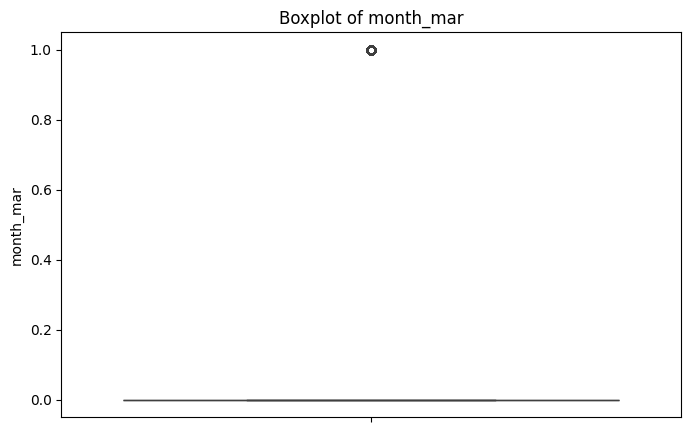

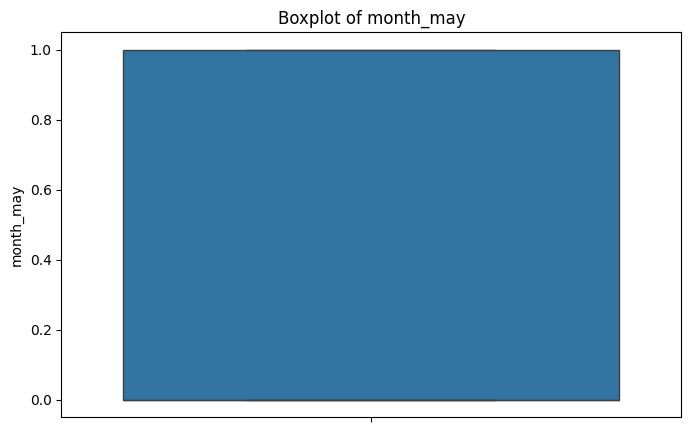

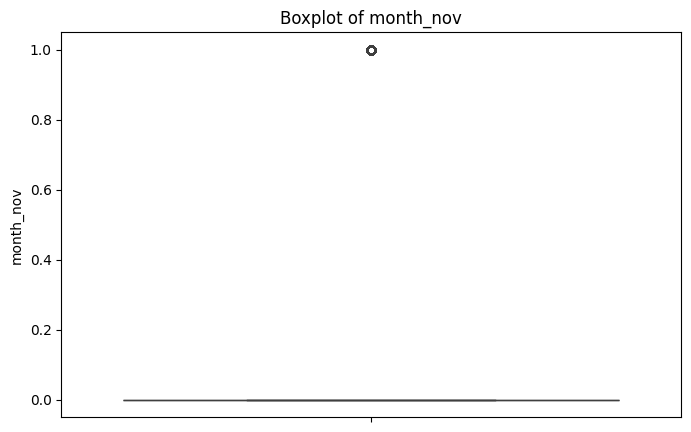

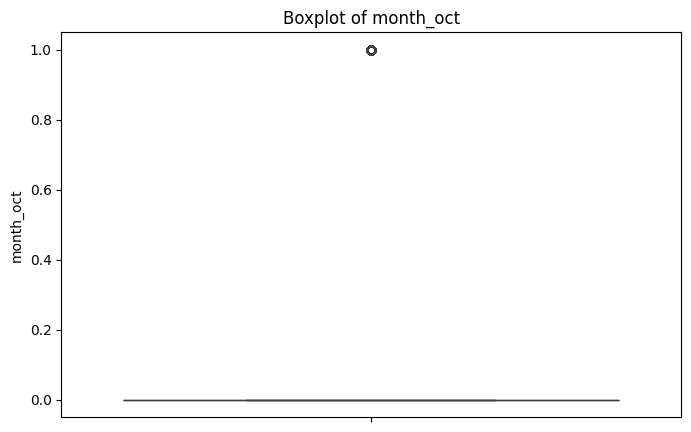

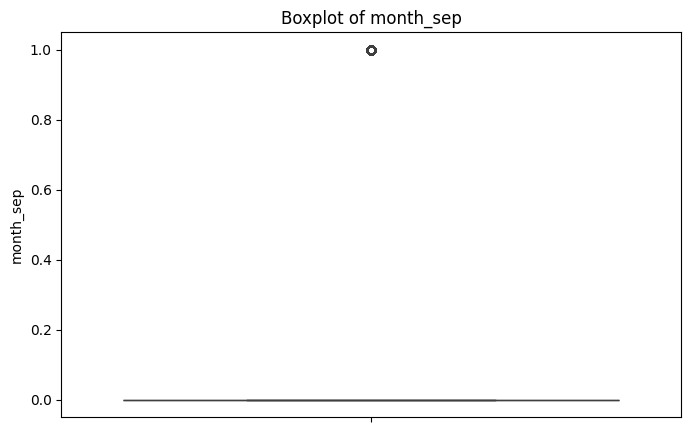

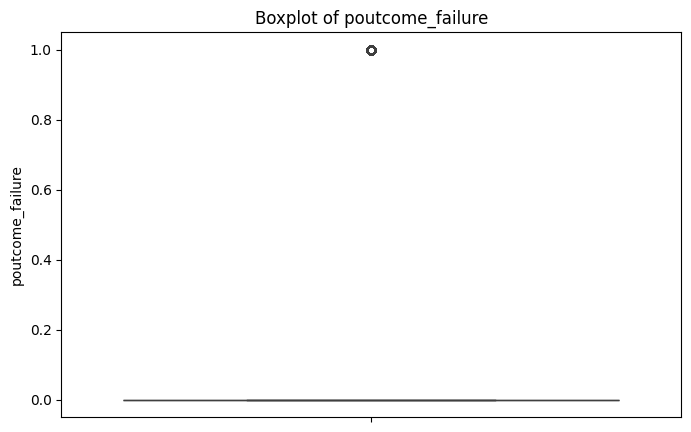

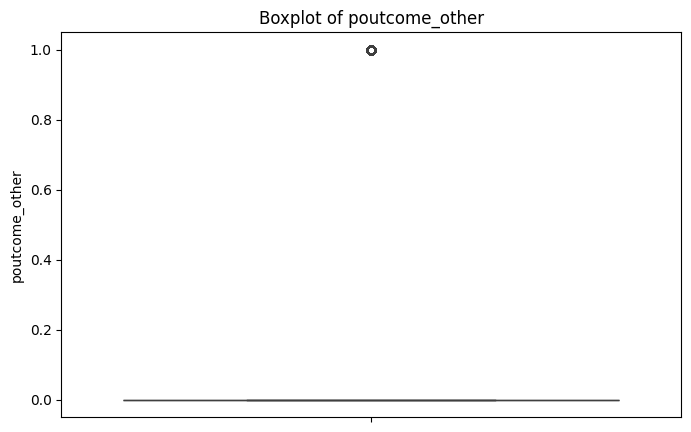

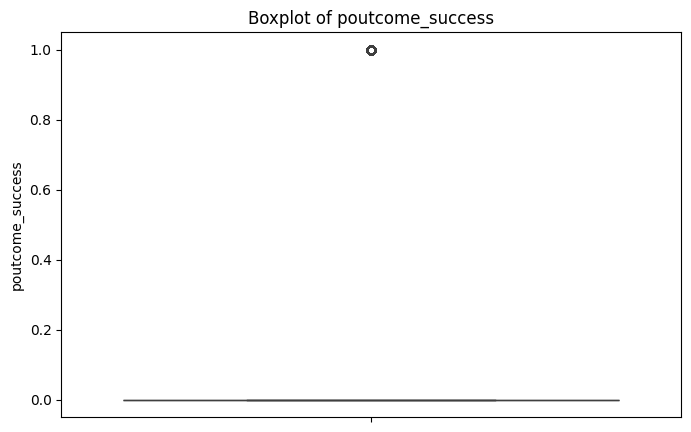

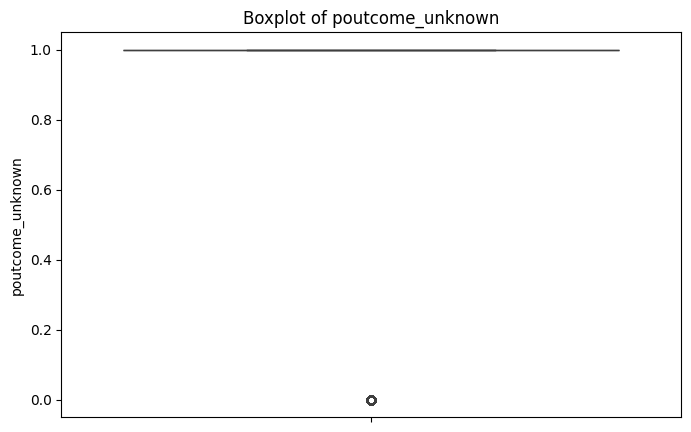

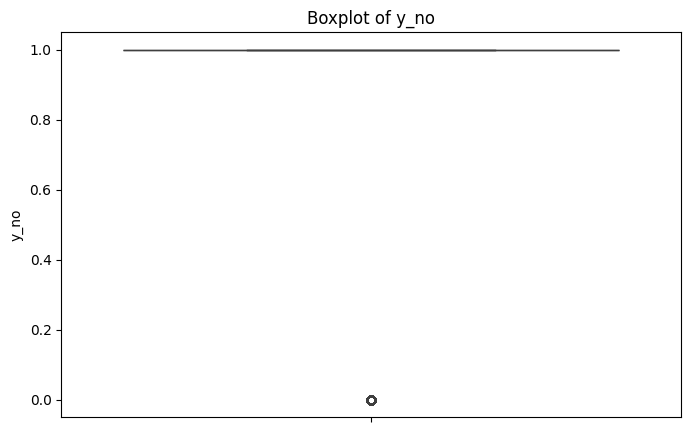

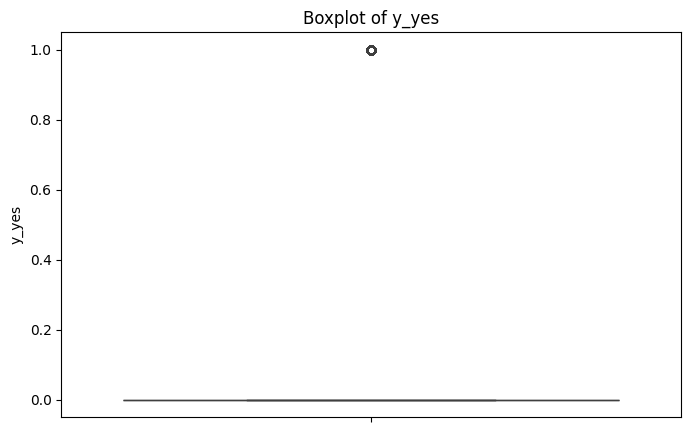

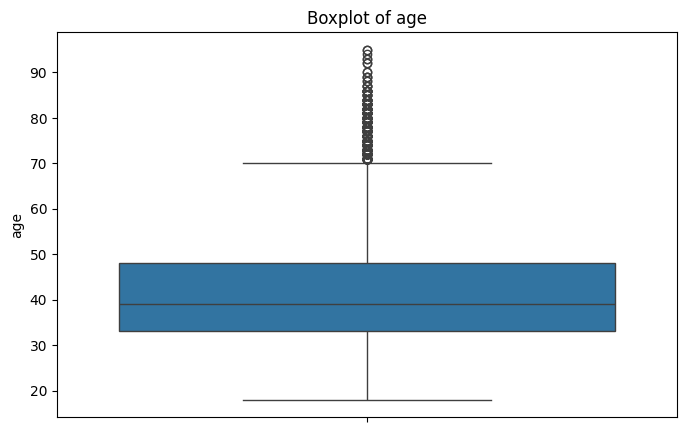

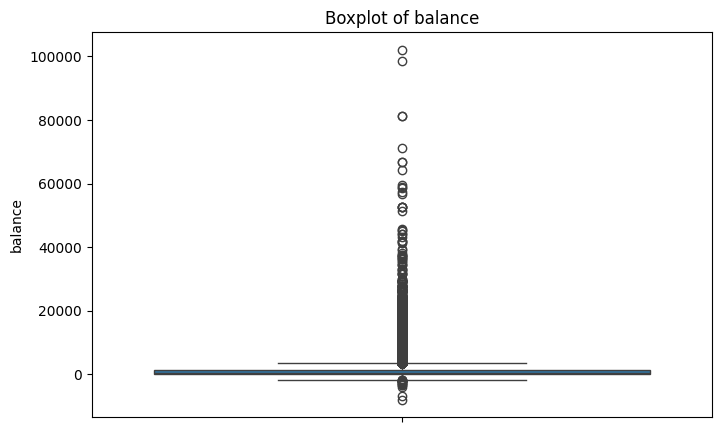

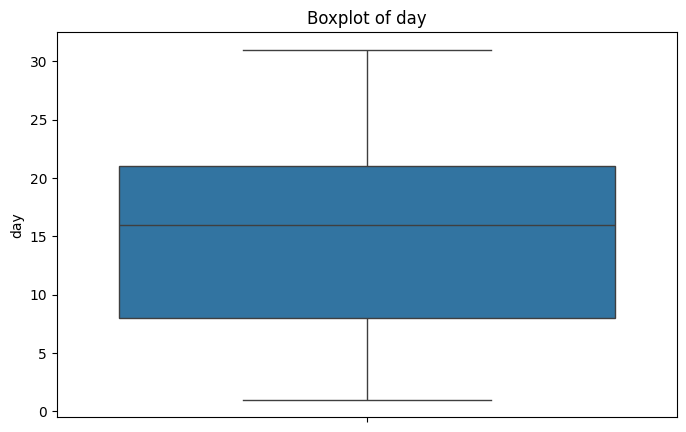

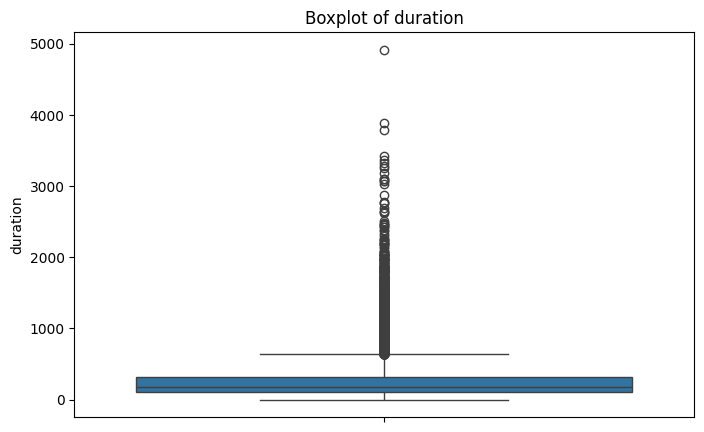

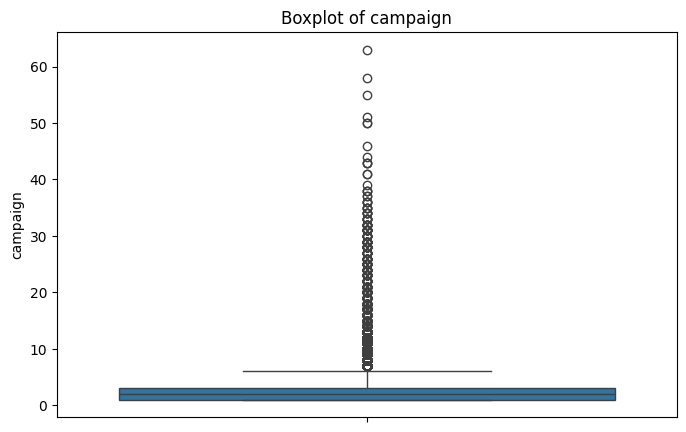

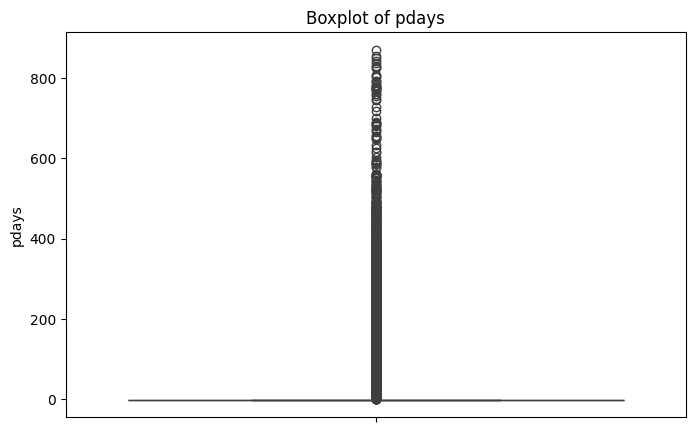

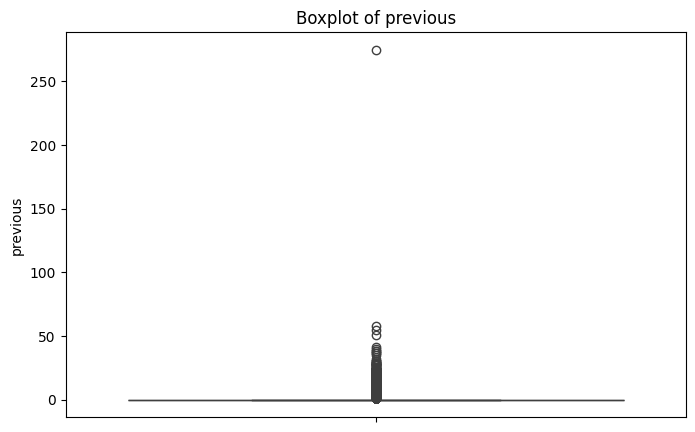

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns
numerical_columns = encoded_data_frame.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots for each numerical column
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=encoded_data_frame[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


In [47]:
# Replace `data_frame` with the actual name of your DataFrame (e.g., cleaned_data, X_train, etc.)
categorical_features = cleaned_data.select_dtypes(include=['object']).columns
numerical_features = cleaned_data.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing: Encode categorical features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),
    ],
    remainder='passthrough'  # Keep numerical columns untouched
)

# Apply preprocessing
encoded_data = preprocessor.fit_transform(cleaned_data)

# Convert the encoded data back to a DataFrame
import pandas as pd
encoded_columns = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_features)
    .tolist()
)
encoded_columns.extend(numerical_features)
encoded_data_frame = pd.DataFrame(encoded_data, columns=encoded_columns)

print("Categorical features encoded successfully!")


Categorical features encoded successfully!


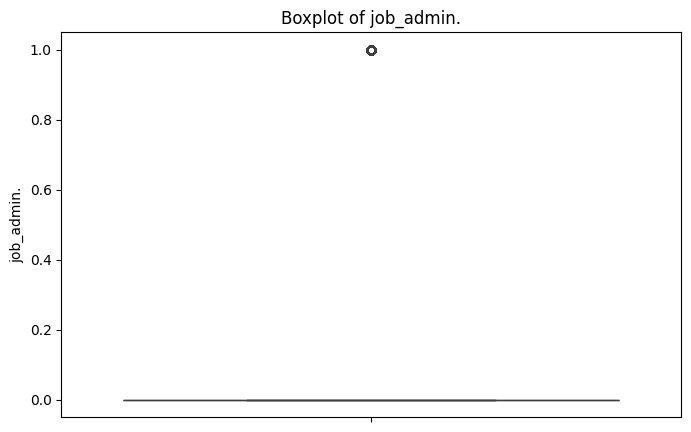

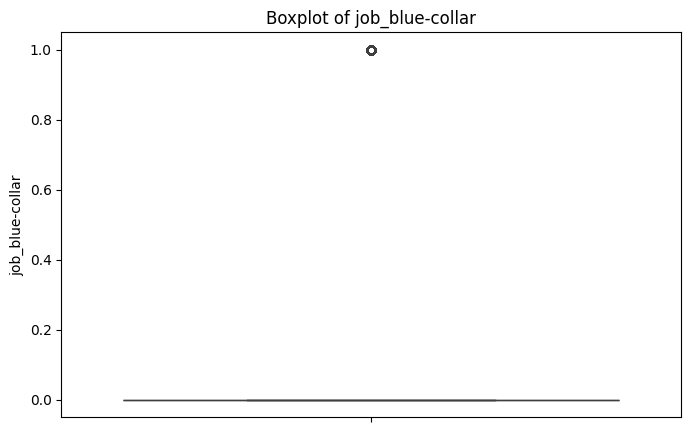

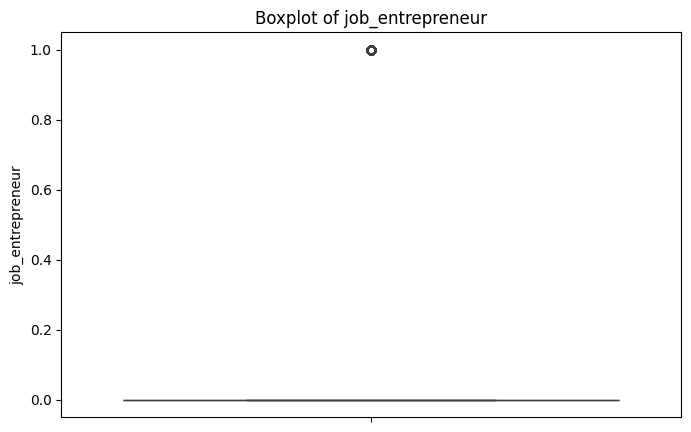

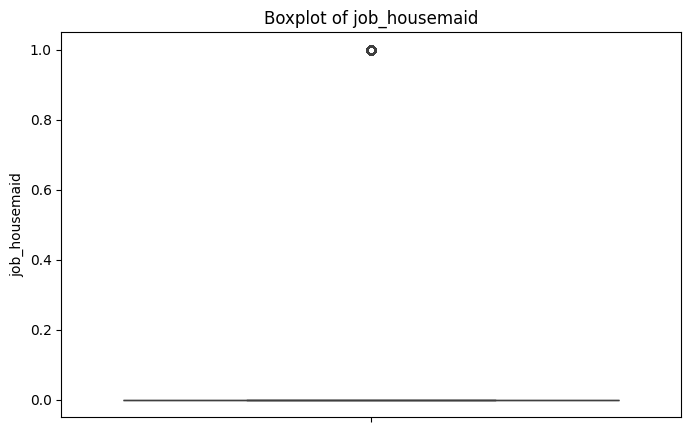

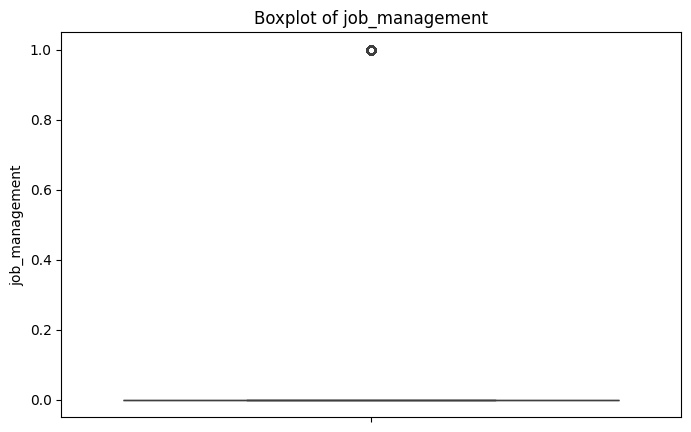

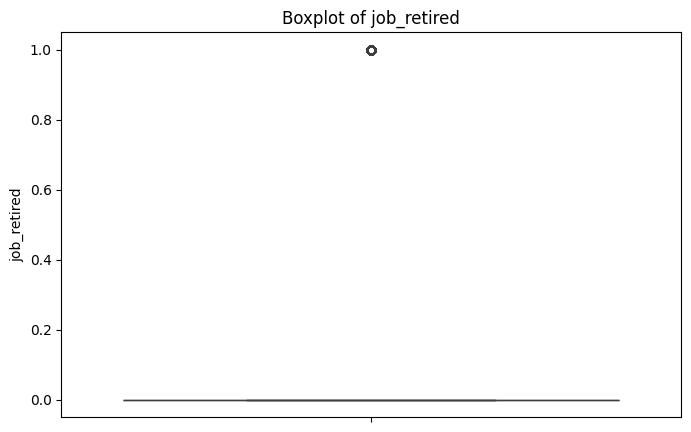

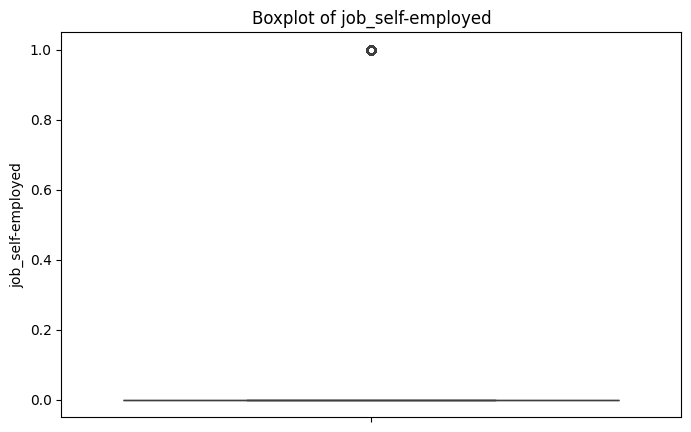

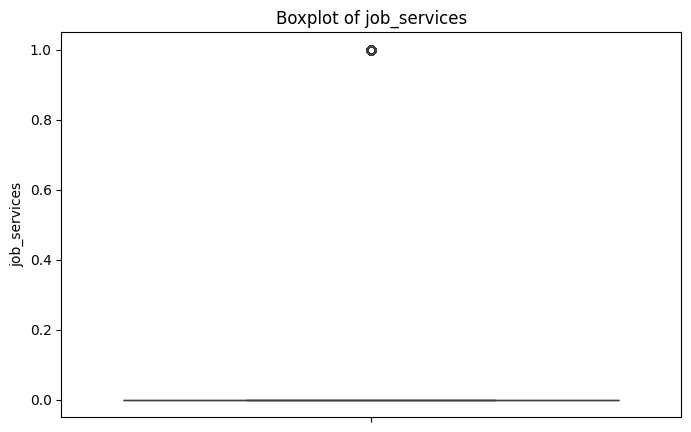

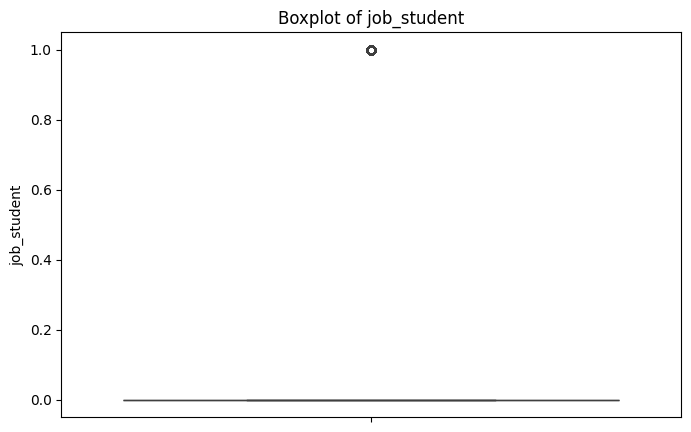

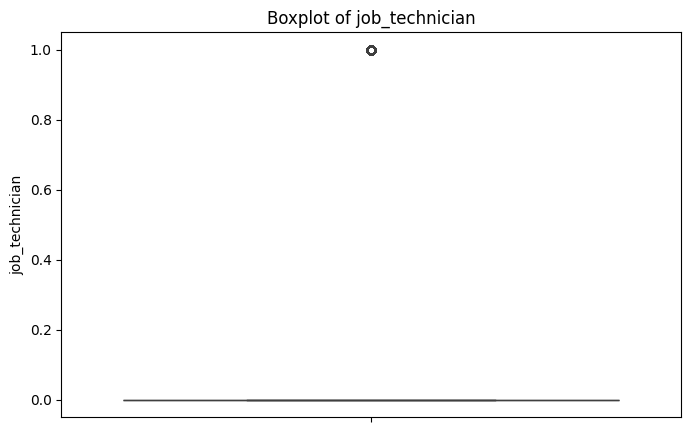

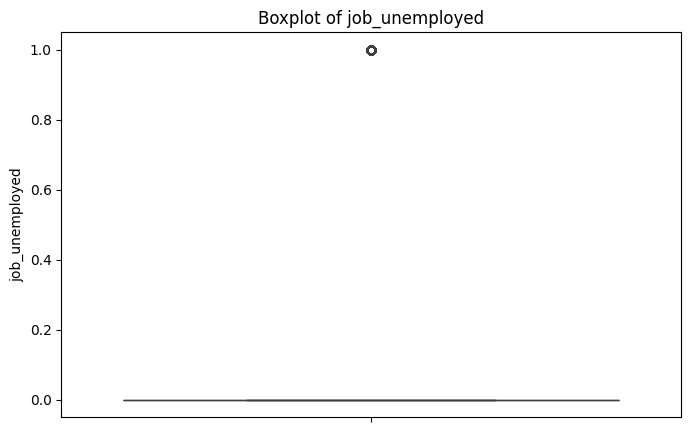

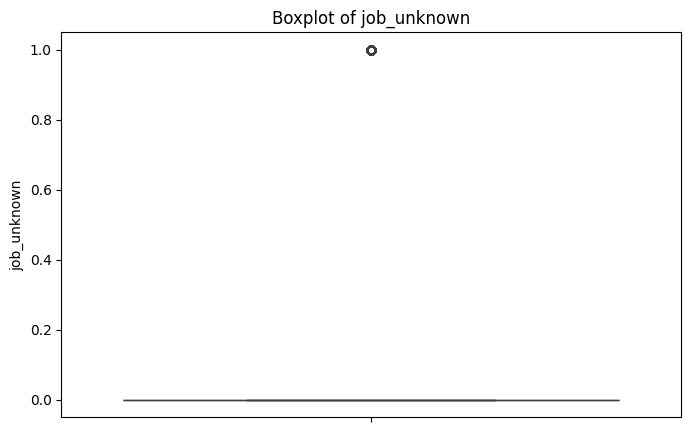

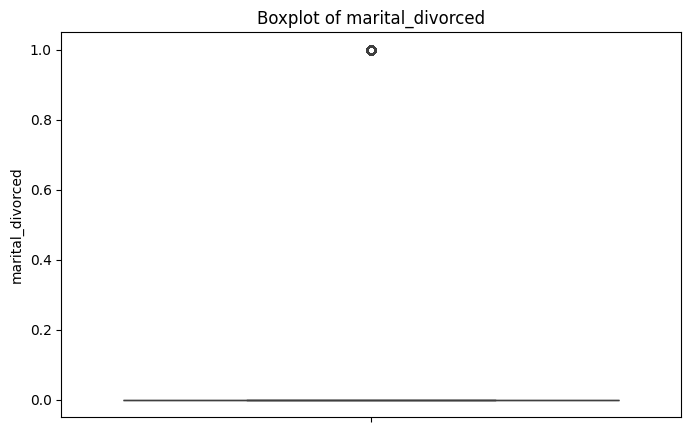

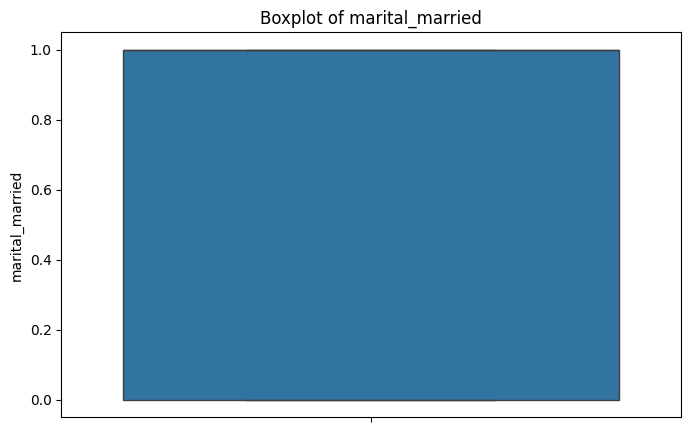

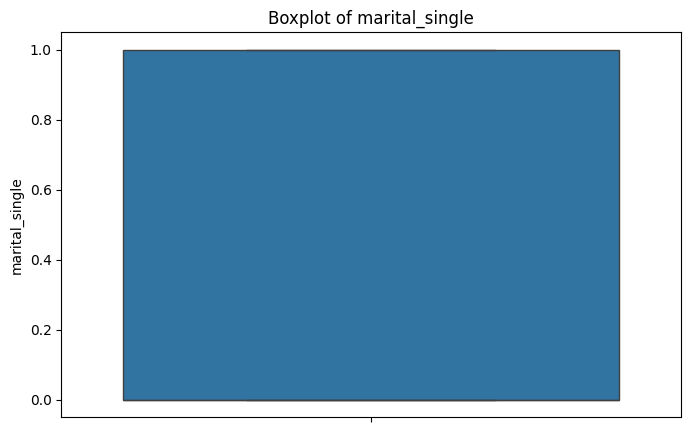

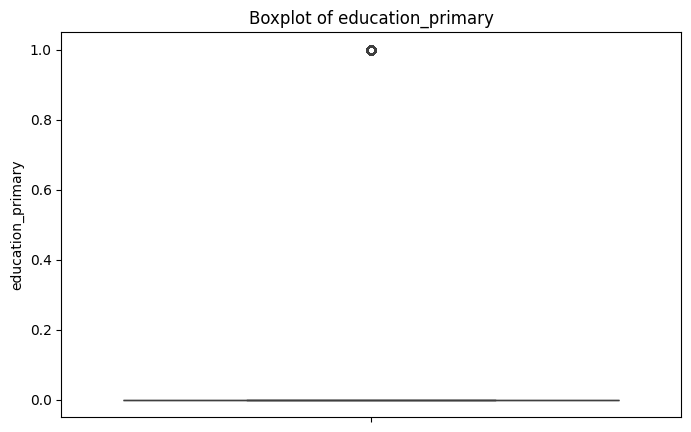

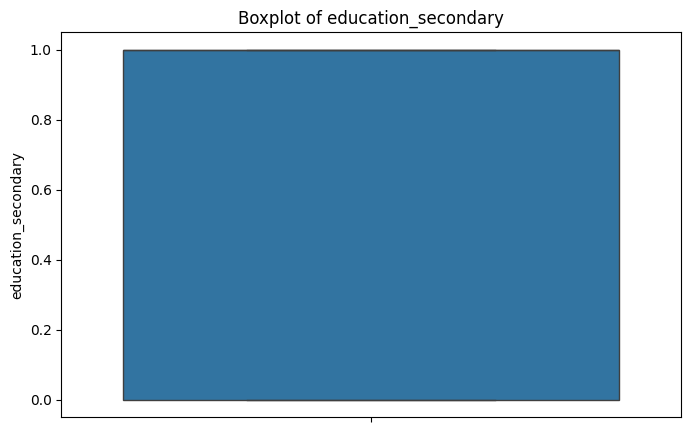

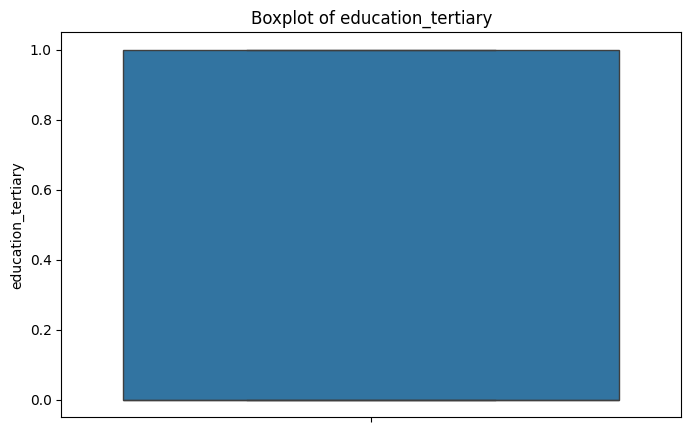

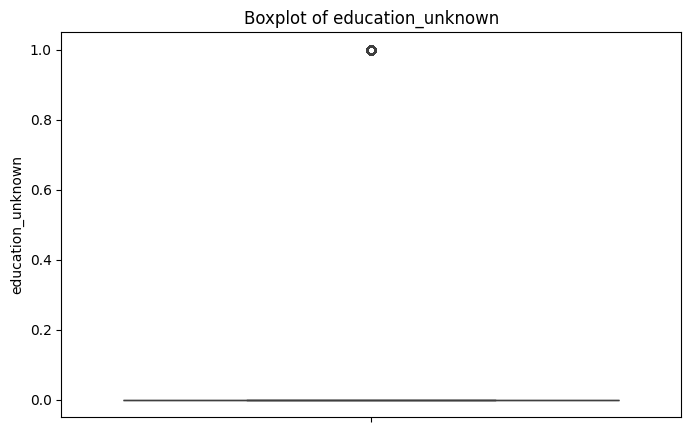

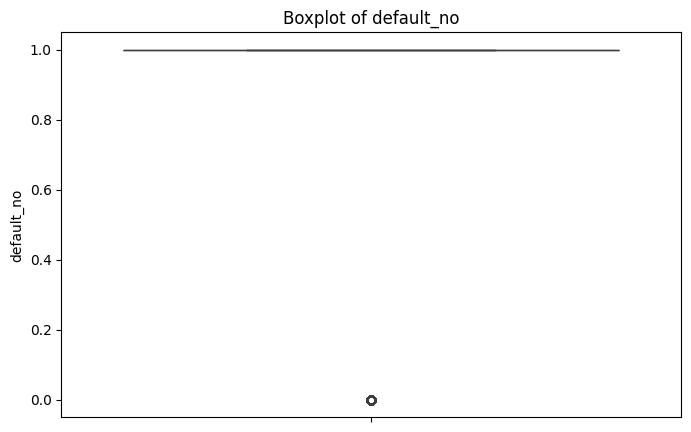

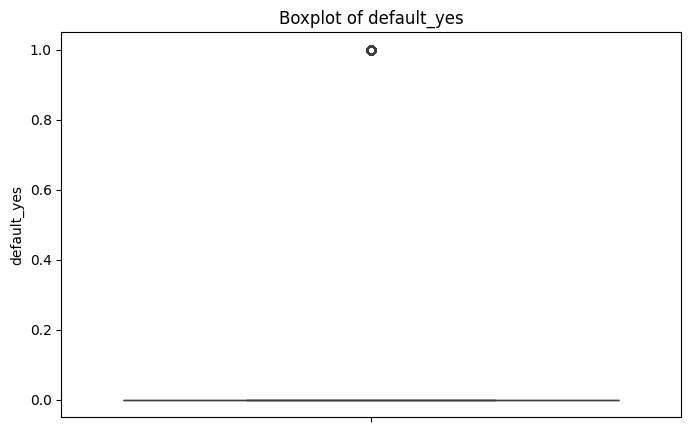

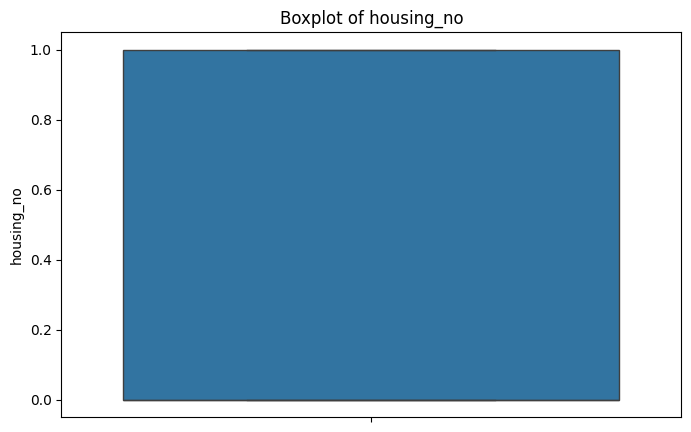

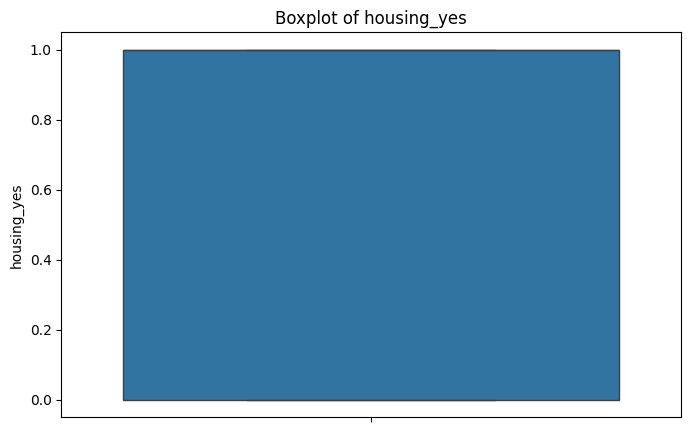

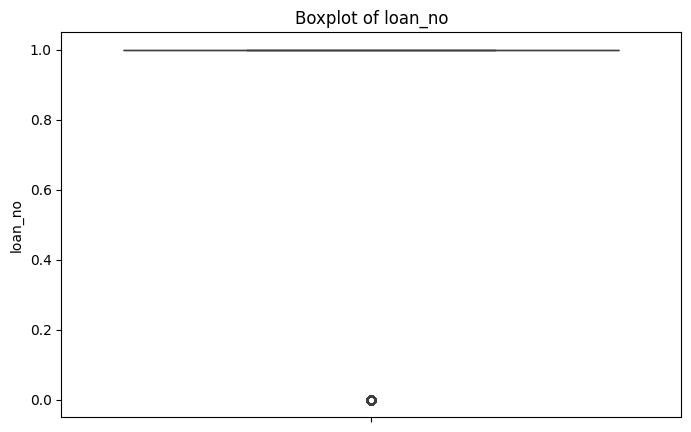

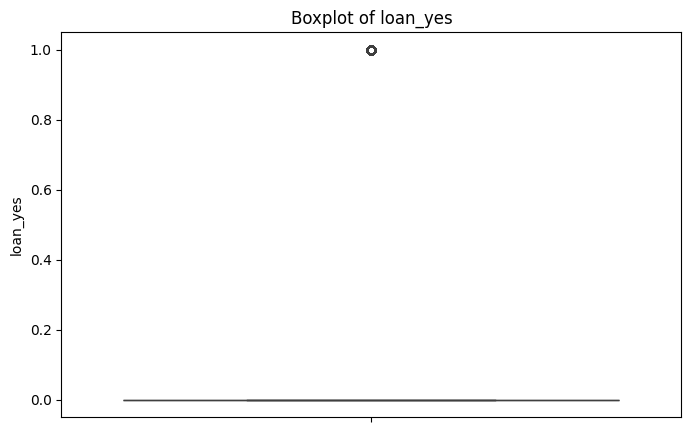

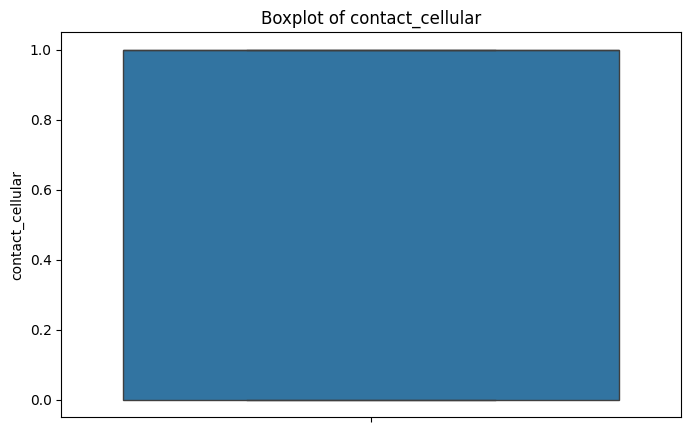

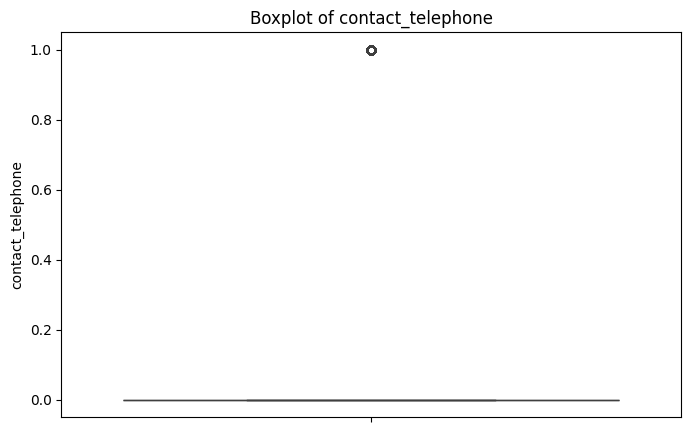

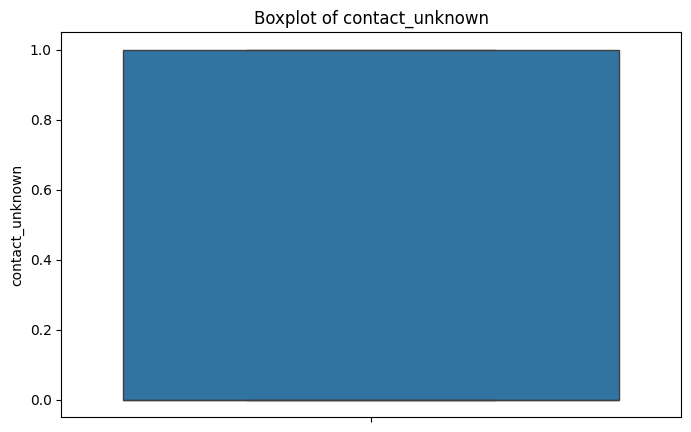

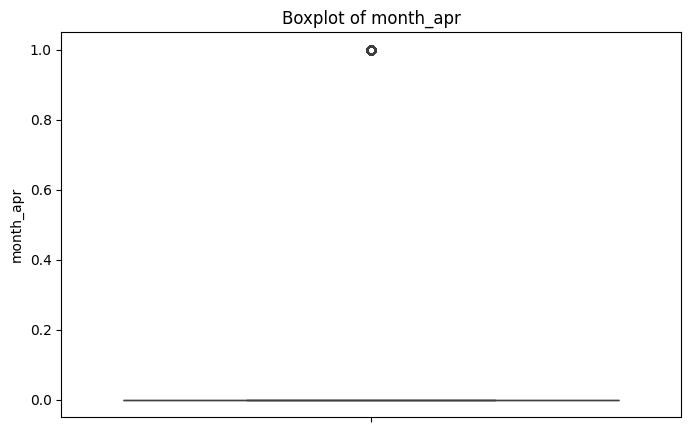

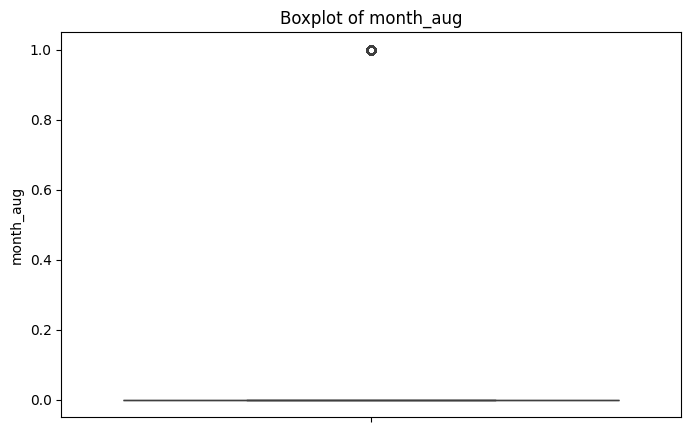

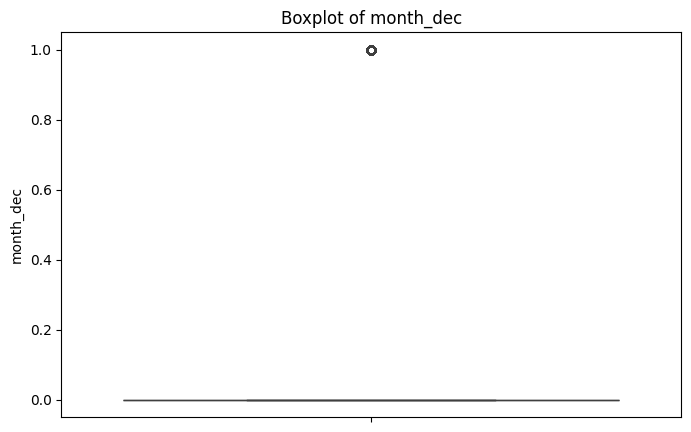

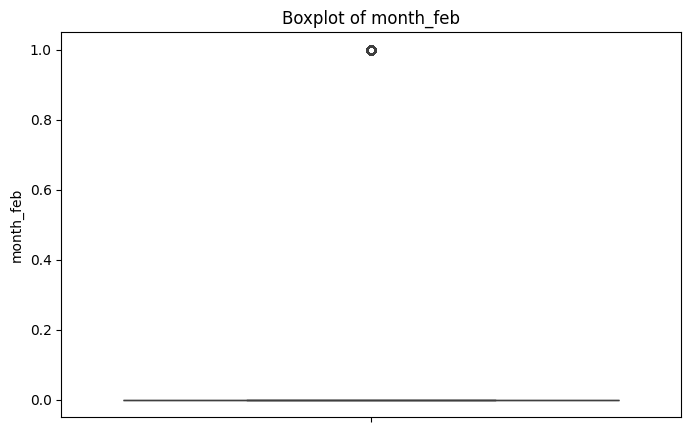

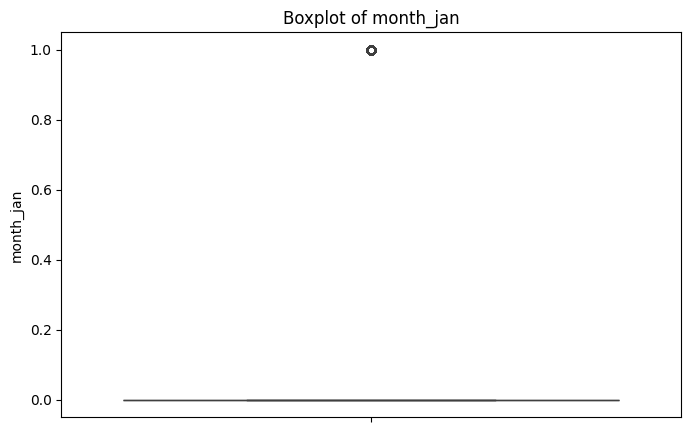

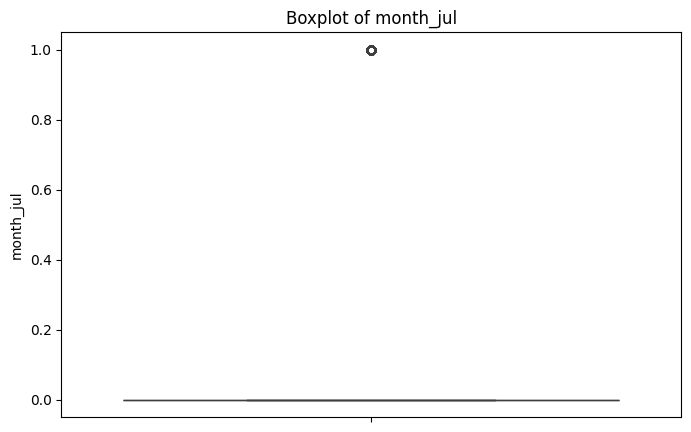

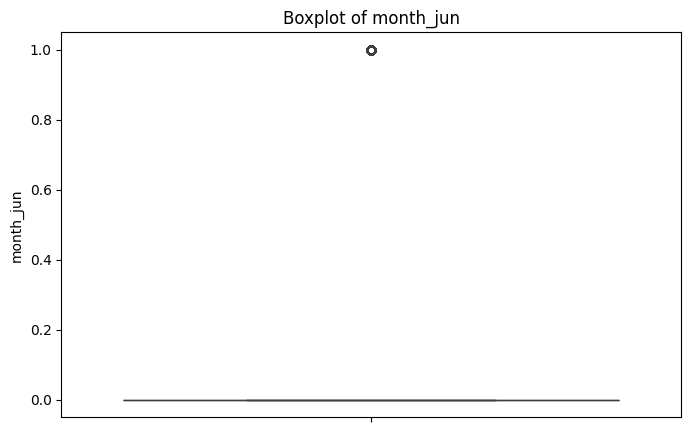

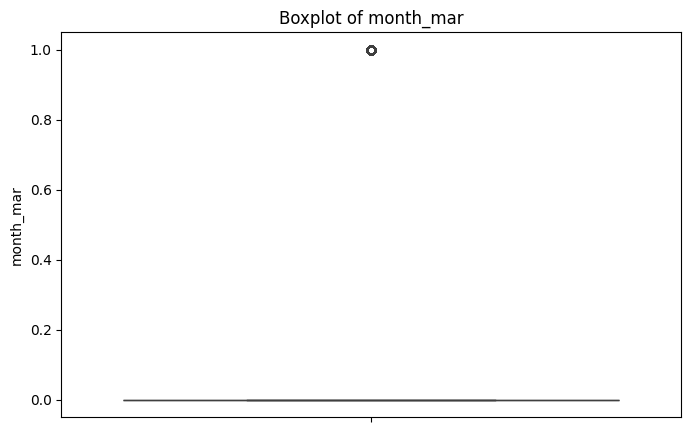

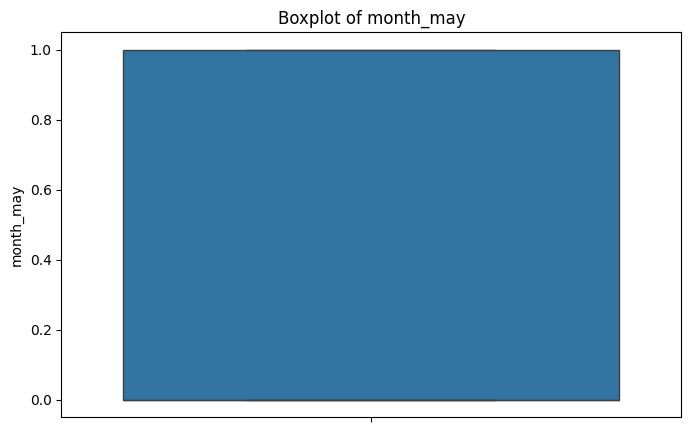

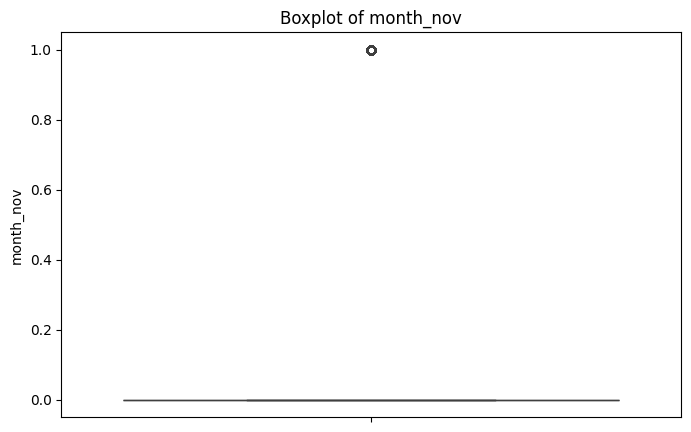

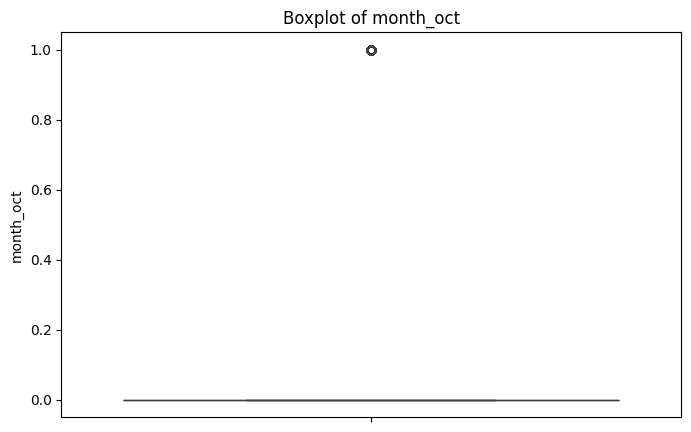

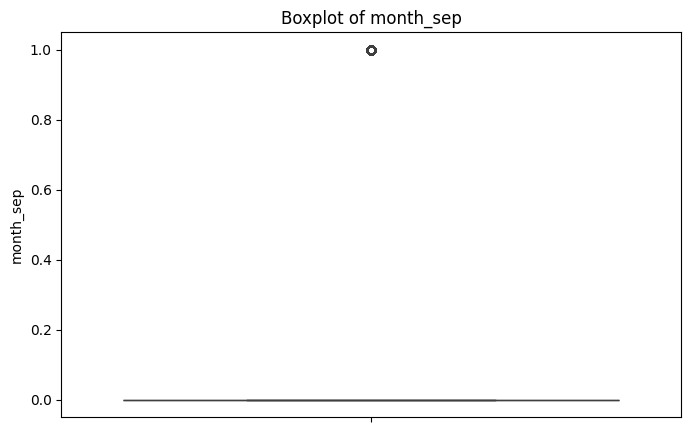

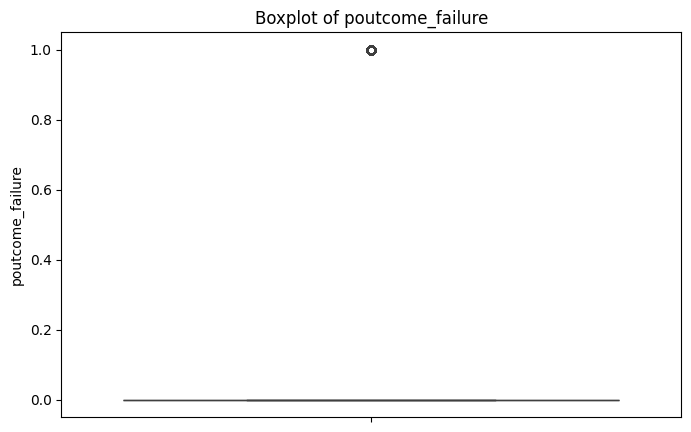

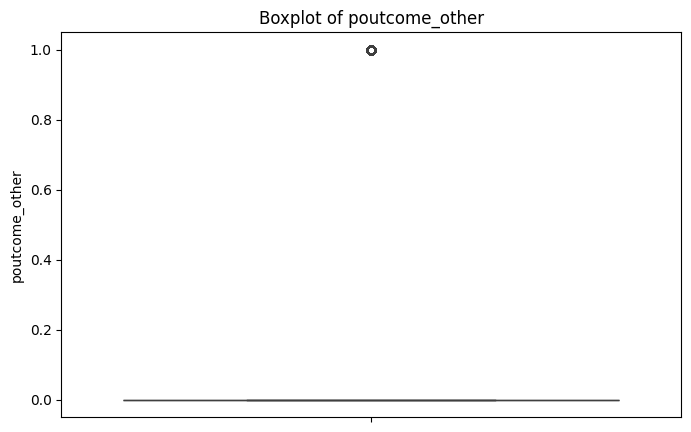

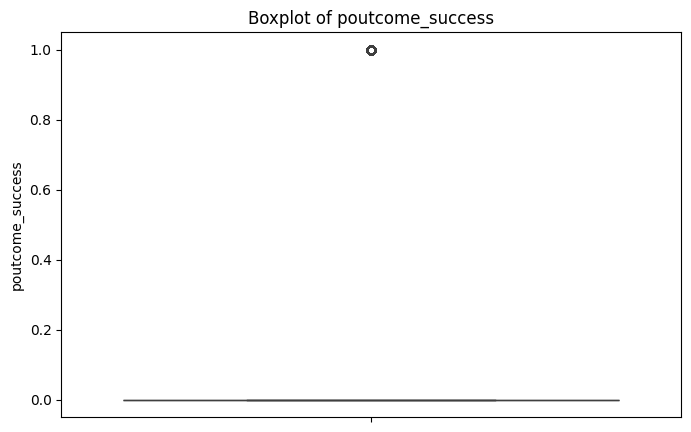

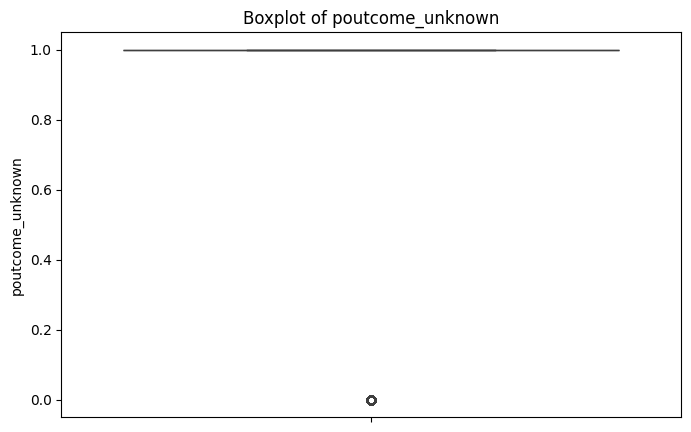

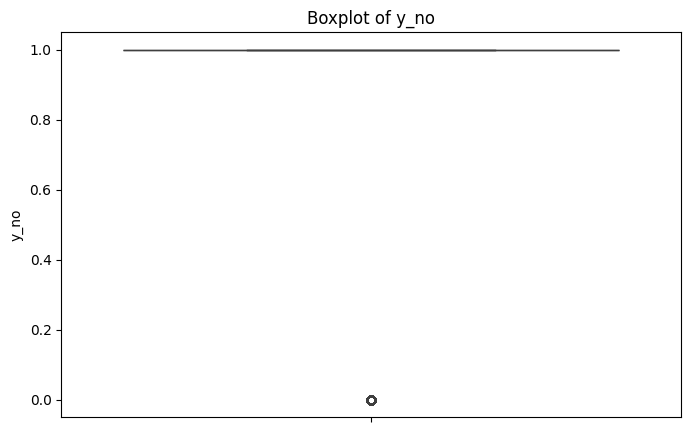

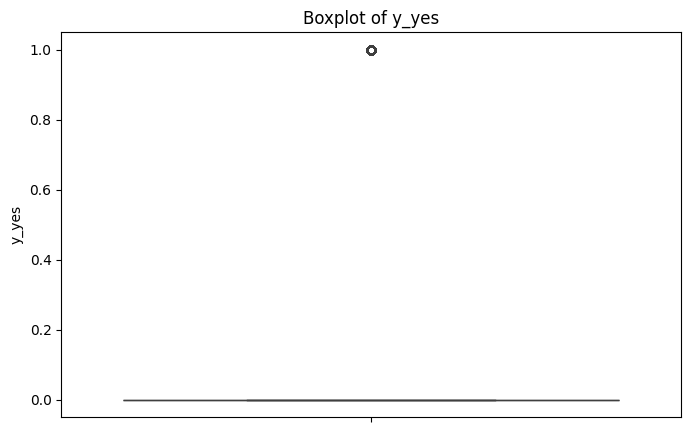

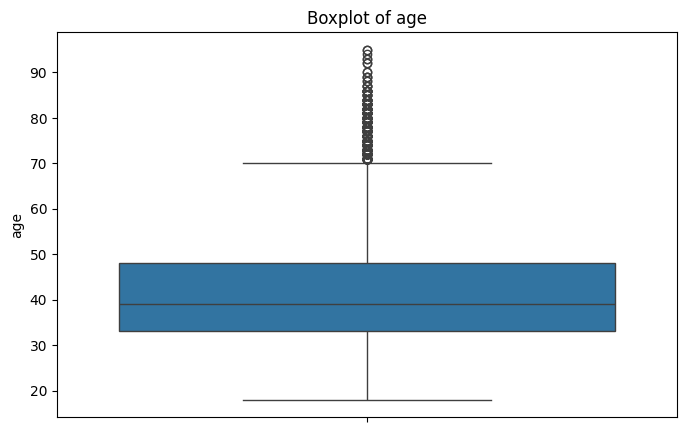

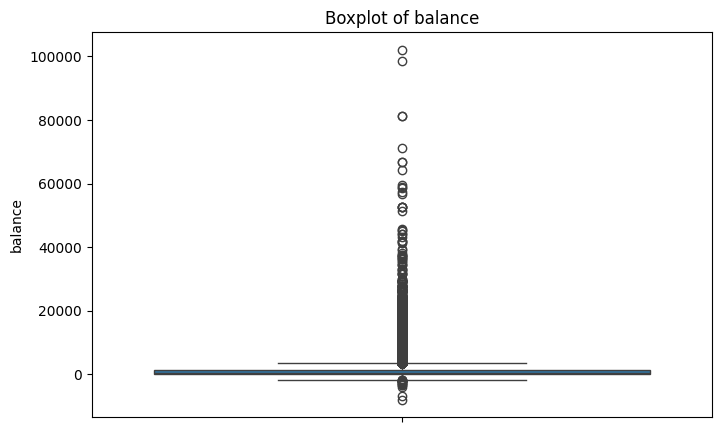

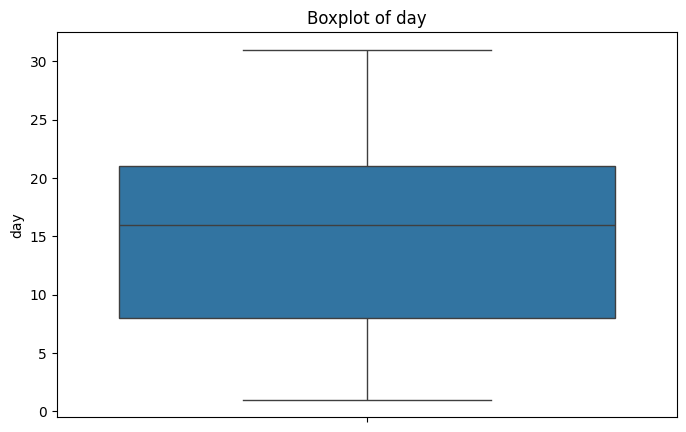

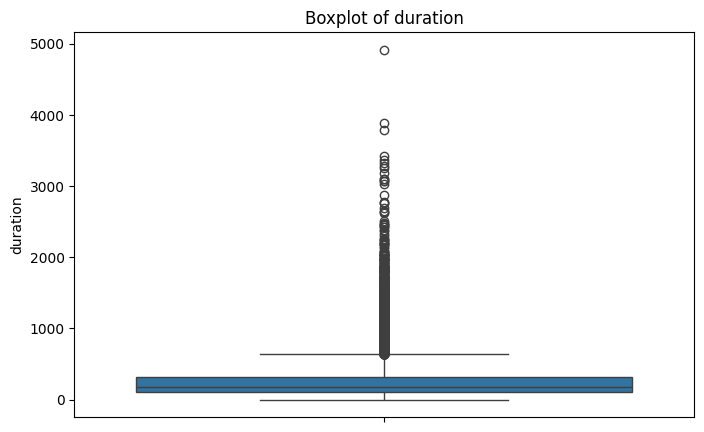

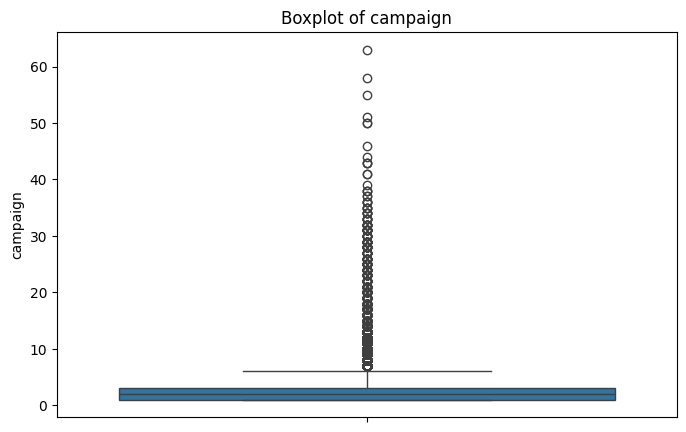

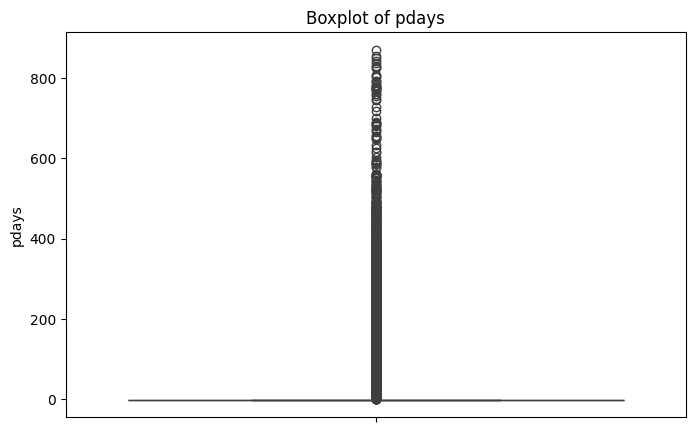

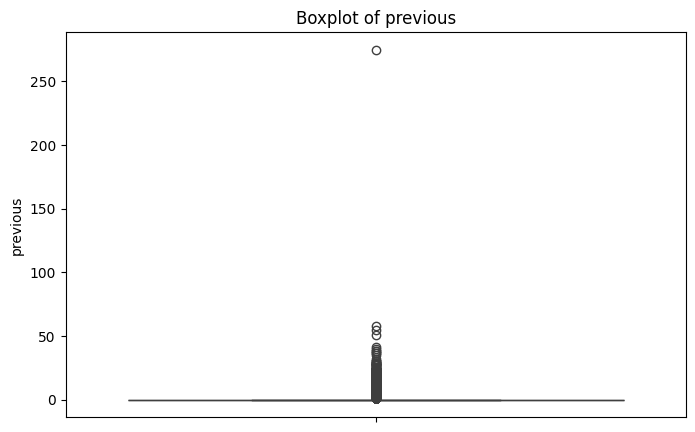

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loop through numerical columns to visualize outliers
for column in encoded_data_frame.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(encoded_data_frame[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


In [50]:
# Example: Handle outliers in a numerical column using IQR
for column in numerical_features:
    Q1 = encoded_data_frame[column].quantile(0.25)
    Q3 = encoded_data_frame[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter or cap outliers
    encoded_data_frame[column] = encoded_data_frame[column].clip(lower_bound, upper_bound)

print("Outliers handled successfully!")


Outliers handled successfully!


In [51]:
# Fill missing values for numerical and categorical features
encoded_data_frame[numerical_features] = encoded_data_frame[numerical_features].fillna(encoded_data_frame[numerical_features].median())

print("Missing values handled successfully!")


Missing values handled successfully!


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
encoded_data_frame[numerical_features] = scaler.fit_transform(encoded_data_frame[numerical_features])

print("Numerical features scaled successfully!")


Numerical features scaled successfully!


In [53]:
# Correlation matrix
correlation_matrix = encoded_data_frame.corr()
print(correlation_matrix)

# Drop highly correlated features based on a threshold
threshold = 0.9
high_corr = [column for column in correlation_matrix if any(correlation_matrix[column] > threshold)]
print("Highly correlated features:", high_corr)


                     job_admin.  job_blue-collar  job_entrepreneur  \
job_admin.             1.000000        -0.188216         -0.066273   
job_blue-collar       -0.188216         1.000000         -0.096585   
job_entrepreneur      -0.066273        -0.096585          1.000000   
job_housemaid         -0.060349        -0.087951         -0.030969   
job_management        -0.184835        -0.269376         -0.094850   
job_retired           -0.082511        -0.120251         -0.042342   
job_self-employed     -0.068364        -0.099633         -0.035082   
job_services          -0.114309        -0.166592         -0.058659   
job_student           -0.052308        -0.076234         -0.026843   
job_technician        -0.161505        -0.235376         -0.082878   
job_unemployed        -0.061907        -0.090223         -0.031768   
job_unknown           -0.028774        -0.041935         -0.014766   
marital_divorced       0.033624        -0.062518          0.003007   
marital_married     

In [55]:
print(encoded_data_frame.columns)


Index(['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'y_no', 'y_yes', 'age', 'balance', 'day',
       'duration', 'campaign', 'pdays', 'previous'],
      dtype='object')


In [57]:
# Use 'y_yes' as the target variable
encoded_data_frame['y'] = encoded_data_frame['y_yes']

# Drop the old 'y_yes' and 'y_no' columns
X = encoded_data_frame.drop(['y', 'y_yes', 'y_no'], axis=1)
y = encoded_data_frame['y']


In [58]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")


Data split successfully!
